# Cross-slope salt transport

CDW carries a substantial ammount of salt with it to the shelf. So checking how the cross-slope salt transport changes with resolution is a useful proxy to see if changes we see in Eddy HT could be associated with CDW inflow

In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
from dask.distributed import Client
from scipy.interpolate import interp1d

import xarray as xr
import cf_xarray as cfxr

In [2]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 56
Total threads: 56,Total memory: 251.18 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40089,Workers: 56
Dashboard: http://127.0.0.1:8787/status,Total threads: 56
Started: Just now,Total memory: 251.18 GiB
Comm: tcp://127.0.0.1:38269,Total threads: 1
Dashboard: http://127.0.0.1:46371/status,Memory: 4.49 GiB
Nanny: tcp://127.0.0.1:41649,


In [3]:
#panan01 daily as f(z,time)
src_p01 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSsaltT_daily_z/*'
#panan005 daily as f(z,time)
src_p005 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/CSsaltT_daily_z/*'


lat_slice  = slice(-83,-59)
figdir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [4]:
#importing panan01
import glob
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p01_ST=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

#importing panan005
gl =glob.glob(src_p005)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p005_ST=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

12 netcdf data files


0.3.0
12 netcdf data files


In [31]:
import glob
src_p01='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_daily_z/*'
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})
(p01_HT.unbinned_heat_transp_across_contour.mean('time').sum('contour_index').sum()/1e12).compute()
#meanP = p01_HT.Unbinned_Heat_transport.mean('time').sum('contour_index').compute()

12 netcdf data files


<xarray.DataArray 'unbinned_heat_transp_across_contour' ()>
array(-30.912273, dtype=float32)

In [7]:
#importing panan01
import glob
src_p01='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_daily_rho/*'
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
pρ01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested')


12 netcdf data files


In [45]:
meanPrho = pρ01_HT.binned_HTplusZC.mean('time').sum('lon_bin_midpoints').compute()

(37.4, 30.2)

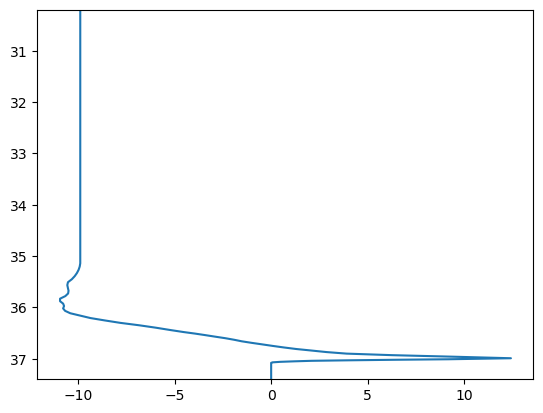

In [51]:
plt.plot(meanPrho[::-1].cumsum()*0.08/1e12,meanPrho.rho2_l[::-1]-1000)
plt.ylim(37.4,30.2)

In [7]:
exp01 = 'panant-01-zstar-ACCESSyr2'
exp005 = 'panant-005-zstar-ACCESSyr2'
start_time= '2000-01-01'
end_time= '2000-12-31'
lat_range = slice(-90,-59)
isobath_depth = 1000
rho_0 = 1035.0

session = cc.database.create_session()

In [ ]:
#volume for averaging
Vol01 = cc.querying.getvar(exp01, 'volcello', session,start_time=start_time, end_time=end_time,ncfile='%daily_z%',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(time=slice(start_time,end_time)).sel(yh=lat_range).isel(z_l=slice(0,51))
Vol005 = cc.querying.getvar(exp005, 'volcello', session,start_time=start_time, end_time=end_time,ncfile='%daily_z%',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(time=slice(start_time,end_time)).sel(yh=lat_range).isel(z_l=slice(0,51))

#Vol Along contour
Vol01 = Vol01.sel(xh=p01_ST.isel(time=0).lon_along_contour.drop('time'),yh=p01_ST.isel(time=0).lat_along_contour.drop('time'),method='nearest')
Vol005 = Vol005.sel(xh=p005_ST.isel(time=0).lon_along_contour.drop('time'),yh=p005_ST.isel(time=0).lat_along_contour.drop('time'),method='nearest')

Vol01 =Vol01.compute()
Vol005=Vol005.compute()

0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0
0.3.0


2024-01-19 07:23:27,352 - distributed.utils_perf - WARNING - full garbage collections took 41% CPU time recently (threshold: 10%)
2024-01-19 07:23:27,870 - distributed.utils_perf - WARNING - full garbage collections took 45% CPU time recently (threshold: 10%)
2024-01-19 07:23:28,360 - distributed.utils_perf - WARNING - full garbage collections took 53% CPU time recently (threshold: 10%)
2024-01-19 07:23:28,869 - distributed.utils_perf - WARNING - full garbage collections took 83% CPU time recently (threshold: 10%)
2024-01-19 07:23:29,283 - distributed.utils_perf - WARNING - full garbage collections took 85% CPU time recently (threshold: 10%)
2024-01-19 07:23:29,716 - distributed.utils_perf - WARNING - full garbage collections took 86% CPU time recently (threshold: 10%)
2024-01-19 07:23:30,145 - distributed.utils_perf - WARNING - full garbage collections took 86% CPU time recently (threshold: 10%)
2024-01-19 07:23:30,574 - distributed.utils_perf - WARNING - full garbage collections took

In [26]:
#importing mass transports
MT01=xr.open_dataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/vol_transp_across_1000m_isobath_panan_01deg_jra55_ryf_1m_2000.nc')
MT005=xr.open_dataset('/g/data/e14/cs6673/mom6_comparison/data_DSW/vol_transp_across_1000m_isobath_panan_005deg_jra55_ryf_1m_2000.nc')
refsigma=np.array(MT01.rho2_l) #target sigmas to interpoalte

MT005mean=MT005.vol_trans_across_contour.mean('time')
MT01mean=MT01.vol_trans_across_contour.mean('time')

In [ ]:
#density for future remapping. remapping can only be done on monthly data
sigma01 = cc.querying.getvar(exp01, 'rhopot2', session,start_time=start_time, end_time=end_time,ncfile='%month%',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(time=slice(start_time,end_time)).sel(yh=lat_range).isel(z_l=slice(0,51))
sigma005 = cc.querying.getvar(exp005, 'rhopot2', session,start_time=start_time, end_time=end_time,ncfile='%month%',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(time=slice(start_time,end_time)).sel(yh=lat_range).isel(z_l=slice(0,51))

#on christinas contour
sigma01c = sigma01.sel(xh=MT01.lon,yh=MT01.lat,method='nearest').mean('time')
sigma005c = sigma005.sel(xh=MT005.lon,yh=MT005.lat,method='nearest').mean('time')


#Vol Along contour
sigma01 = sigma01.sel(xh=p01_ST.isel(time=0).lon_along_contour.drop('time'),yh=p01_ST.isel(time=0).lat_along_contour.drop('time'),method='nearest')
sigma005 = sigma005.sel(xh=p005_ST.isel(time=0).lon_along_contour.drop('time'),yh=p005_ST.isel(time=0).lat_along_contour.drop('time'),method='nearest')


sigma01 =sigma01.compute()
sigma005=sigma005.compute()
sigma01c =sigma01c.compute()
sigma005c=sigma005c.compute()

2024-01-19 07:30:35,941 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2024-01-19 07:30:36,539 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)
2024-01-19 07:30:37,509 - distributed.utils_perf - WARNING - full garbage collections took 11% CPU time recently (threshold: 10%)


# Mean CSST

Notice that the salt transport is in Kg of salt per sec

In [9]:
mp01_ST = p01_ST.groupby('time.month').mean('time').mean('month').sum('z_l')
mp005_ST = p005_ST.groupby('time.month').mean('time').mean('month').sum('z_l')
mzp01_ST = p01_ST.groupby('time.month').mean('time').mean('month')
mzp005_ST = p005_ST.groupby('time.month').mean('time').mean('month')


In [10]:
#Calculating binned and unbinned vars and cumsum - PANAN01
mp01_STunbinned=mp01_ST.unbinned_salt_transp_across_contour.cumsum()
factor01=mp01_STunbinned.max()/( (mp01_ST.binned_cross_slope_salt_trans.sum()) + (mp01_ST.zonal_convergence.sum())  )
mp01_STbinned=(mp01_ST.binned_cross_slope_salt_trans*factor01).cumsum()
mp01_STZC=(mp01_ST.zonal_convergence*factor01).cumsum()
mp01_STbinnedZC=( (mp01_ST.binned_cross_slope_salt_trans + mp01_ST.zonal_convergence)*factor01 ).cumsum()

#Calculating binned and unbinned vars and cumsum - PANAN005
mp005_STunbinned=mp005_ST.unbinned_salt_transp_across_contour.cumsum()
factor005=mp005_STunbinned.max()/( (mp005_ST.binned_cross_slope_salt_trans.sum()) + (mp005_ST.zonal_convergence.sum())  )
mp005_STbinned=(mp005_ST.binned_cross_slope_salt_trans*factor005).cumsum()
mp005_STZC=(mp005_ST.zonal_convergence*factor005).cumsum()
mp005_STbinnedZC=( (mp005_ST.binned_cross_slope_salt_trans + mp005_ST.zonal_convergence)*factor005 ).cumsum()

In [11]:
# Here we are assuming that all negative salt transport is due to the CDW
CDWmzp01_ST=( mzp01_ST.binned_cross_slope_salt_trans + mzp01_ST.zonal_convergence)*factor01
CDWmzp01_ST=CDWmzp01_ST.where(CDWmzp01_ST<0).sum('z_l')

CDWmzp005_ST=( mzp005_ST.binned_cross_slope_salt_trans + mzp005_ST.zonal_convergence)*factor005
CDWmzp005_ST=CDWmzp005_ST.where(CDWmzp005_ST<0).sum('z_l')


First evaluation for CSST, how does it compareto the zonal convegence on panan01?

Text(0.5, 1.0, 'Sum of Southward Transports')

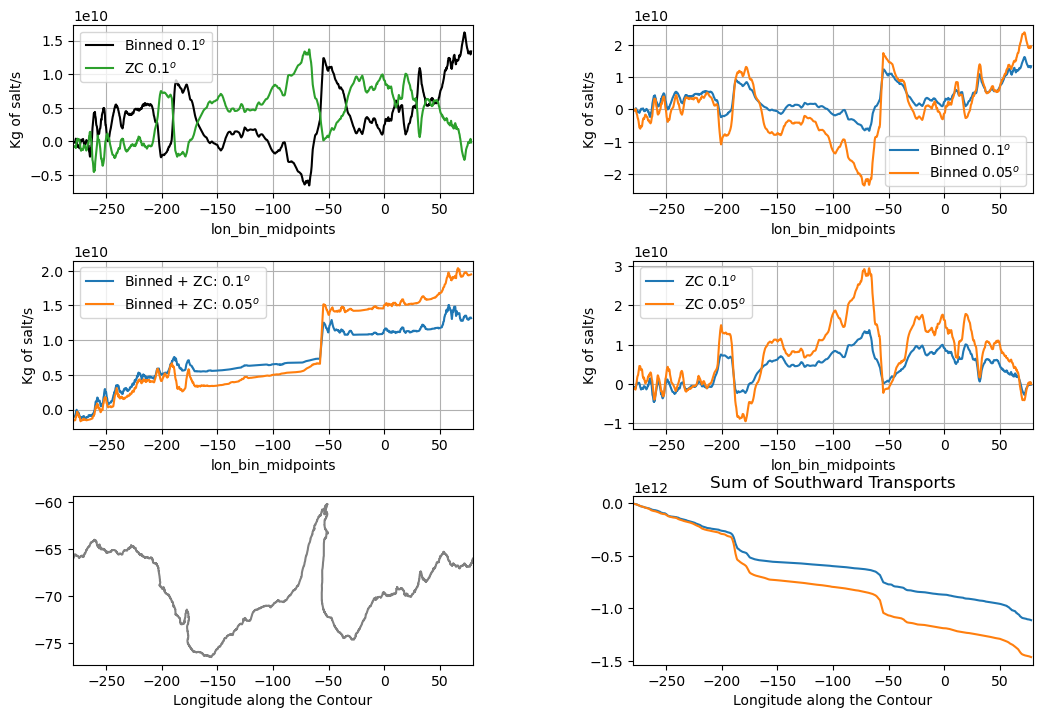

In [12]:
plt.figure(figsize=(12, 8))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(3,2,1)
(factor01*mp01_STbinned).plot(color='black',label=r"Binned $0.1^o$")
(factor01*mp01_STZC).plot(color='tab:green',label=r"ZC $0.1^o$")
plt.grid(); plt.legend(); plt.xlim(-280,80)
plt.ylabel('Kg of salt/s')

plt.subplot(3,2,2)
(factor01*mp01_STbinned).plot(color='tab:blue',label=r"Binned $0.1^o$")
(factor005*mp005_STbinned).plot(color='tab:orange',label=r"Binned $0.05^o$")
plt.grid(); plt.legend(); plt.xlim(-280,80)
plt.ylabel('Kg of salt/s');


plt.subplot(3,2,3)
(factor01*mp01_STbinnedZC).plot(color='tab:blue',label=r"Binned + ZC: $0.1^o$")
(factor005*mp005_STbinnedZC).plot(color='tab:orange',label=r"Binned + ZC: $0.05^o$")
plt.grid(); plt.legend(); plt.xlim(-280,80)
plt.ylabel('Kg of salt/s')


plt.subplot(3,2,4)
(factor01*mp01_STZC).plot(color='tab:blue',label=r"ZC $0.1^o$")
(factor005*mp005_STZC).plot(color='tab:orange',label=r"ZC $0.05^o$")
plt.grid(); plt.legend(); plt.xlim(-280,80)
plt.ylabel('Kg of salt/s');

plt.subplot(3,2,5)
plt.plot(p005_ST.isel(time=0).lon_along_contour.drop('time'),
         p005_ST.isel(time=0).lat_along_contour.drop('time'), color='grey')
plt.xlabel('Longitude along the Contour'); plt.xlim(-280,80)


plt.subplot(3,2,6)
CDWmzp01_ST.cumsum().plot(color='tab:blue',label=r"CDW $0.1^o$")
CDWmzp005_ST.cumsum().plot(color='tab:orange',label=r"ZC $0.05^o$")
plt.xlabel('Longitude along the Contour'); plt.xlim(-280,80)
plt.title('Sum of Southward Transports')

What do we take from these plots?

1- It seems to me that the zonal convergence largely compensate the CSSalt transport (top)

2- There are 3 main regions where the salt Southward salt transport is so strong that it actually can be seen in the cumulative sum. one is around 280W, then ross sea (~200W), and amundsen sea (-200,-150)

3- In the 3 regions above, the Southward Salt transport increase with resolution ( More southward salt transport as resolution increases)

4- the signals in the zonal convergence increase with resolution too

5- the total CCSalt transport is positive (northward) in all cases, and increases with resolution

6- For the plot on bottom left we assumed all Southward Transport corresponds to CDW entrance. If that assumption is valid, than the stronger negative salt tranport in the higher resolution suggests that we likely have more CDW entering the shelf in higher resolutions


# Transports along isopycnals

In [13]:
#importing heat transports
#panan01 daily as f(z,time)
src_p01 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_daily_z/*'
#panan005 daily as f(z,time)
src_p005 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/CSHT_daily_z/*'
#panan0025 daily as f(z,time)
src_p0025 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025/CSHT_monthly_z/*'

#importing panan01
import glob
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

#importing panan005
gl =glob.glob(src_p005)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p005_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

meanp01_HT=p01_HT.groupby('time.month').mean('time').mean('month')
meanp005_HT=p005_HT.groupby('time.month').mean('time').mean('month')

12 netcdf data files


12 netcdf data files


In [14]:
#average sigmas
meansigma01=sigma01.mean('time')
meansigma005=sigma005.mean('time')
#mzp01_ST, mzp005_ST,meanp01_HT,meanp005_HT

We also want the temperature along the contour to be transformed into digma2 space, to see if the changes we see are due to CDW T changes or CDW volume transport changes

In [15]:
## Getting the age in each model cell
#for Panan01
T01 = cc.querying.getvar(exp01, 'thetao', session,start_time=start_time, end_time=end_time,ncfile='%month_z%',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(time=slice(start_time,end_time)).sel(yh=lat_range).mean('time').compute()

#masking offshore regions
outfile = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Antarctic_slope_contour_Panan01_1000m.npz'
P01_mask = np.load(outfile)
P01_maskd=T01.isel(z_l=0).copy(); P01_maskd.values=P01_mask['contour_masked_above']
P01_maskd=(P01_maskd.where(P01_maskd>=0)*0)+1
T01=T01.where(P01_maskd>=0)


#for Panan005
T005 = cc.querying.getvar(exp005, 'thetao', session,start_time=start_time, end_time=end_time,ncfile='%month_z%',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(time=slice(start_time,end_time)).mean('time').sel(yh=lat_range).compute()
#masking offshore regions
outfile = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Antarctic_slope_contour_Panan005_1000m.npz'
P005_mask = np.load(outfile)
P005_maskd=T005.isel(z_l=0).copy(); P005_maskd.values=P005_mask['contour_masked_above']
P005_maskd=(P005_maskd.where(P005_maskd>=0)*0)+1

T005=T005.where(P005_maskd>=0)



### getting values along the isotherm
cT01 = T01.sel(xh=meanp01_HT.lon_along_contour,yh=meanp01_HT.lat_along_contour, method='nearest')
cT005 = T005.sel(xh=meanp005_HT.lon_along_contour,yh=meanp005_HT.lat_along_contour, method='nearest')

2024-01-19 07:37:14,532 - distributed.worker.memory - WARNING - Worker is at 83% memory usage. Pausing worker.  Process memory: 7.49 GiB -- Worker memory limit: 8.97 GiB
2024-01-19 07:37:14,533 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 7.49 GiB -- Worker memory limit: 8.97 GiB
2024-01-19 07:37:15,274 - distributed.worker.memory - WARNING - Worker is at 60% memory usage. Resuming worker. Process memory: 5.40 GiB -- Worker memory limit: 8.97 GiB
2024-01-19 07:37:17,504 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memo

MemoryError: Task ('mean_combine-partial-c69497ceebf33bd014e2b6470bc34f09', 1, 0, 0, 0) has 13.78 GiB worth of input dependencies, but worker tcp://127.0.0.1:36311 has memory_limit set to 8.97 GiB.

In [ ]:
# #volumes along isopycnals for averaging
Vol01ρ = cc.querying.getvar(exp01, 'volcello', session,start_time=start_time, end_time=end_time,ncfile='%month_rho%',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(time=slice(start_time,end_time)).sel(yh=lat_range).mean('time').compute()
Vol005ρ = cc.querying.getvar(exp005, 'volcello', session,start_time=start_time, end_time=end_time,ncfile='%month_rho%',\
                           chunks={'xh':'100gb','yh':'100gb'}).sel(time=slice(start_time,end_time)).sel(yh=lat_range).mean('time').compute()

Vol01ρ=Vol01ρ.sel(xh=meanp01_HT.lon_along_contour,yh=meanp01_HT.lat_along_contour,method='nearest')
Vol005ρ=Vol005ρ.sel(xh=meanp01_HT.lon_along_contour,yh=meanp01_HT.lat_along_contour,method='nearest')

Vol01ρ['rho2_l']=np.array(Vol01ρ.rho2_l-1000)
Vol005ρ['rho2_l']=np.array(Vol005ρ.rho2_l - 1000)

Binning the sigma values for future conversion of the HT/ST to sigma space in the binned array

In [ ]:
# firstm getting area for averaging
area01c=xr.open_dataset('/g/data/ik11/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output000/19910101.ocean_static.nc')\
    .areacello.sel(xh=meanp01_HT.lon_along_contour,yh=meanp01_HT.lat_along_contour,method='nearest')
area005c=xr.open_dataset('/g/data/ik11/outputs/mom6-panan/panant-005-zstar-ACCESSyr2/output000/19910101.ocean_static.nc')\
    .areacello.sel(xh=meanp005_HT.lon_along_contour,yh=meanp005_HT.lat_along_contour,method='nearest')


#2nd adding weights for averaging

meansigma01bin=meansigma01
meansigma005bin=meansigma005
# convert to longitude coordinate and average into 3 degree longitude bins:
# in degrees:
bin_width = 3
bin_spacing = 0.25
lon_west = -280
lon_east = 80
	
# new coordinate and midpoints of longitude bins:
full_lon_coord = np.arange(lon_west,lon_east+bin_spacing,bin_spacing)
lon_bin_midpoints0 = np.arange(lon_west+bin_width/2,lon_east-bin_width/2,bin_spacing)
n_bin_edges = len(full_lon_coord)
lon_along_contour0=np.array(mzp01_ST.lon_along_contour)
lat_along_contour0=np.array(mzp01_ST.lat_along_contour)
lon_along_contour0c=np.array(MT01.lon) #cristina's mass transport contour
lat_along_contour0c=np.array(MT01.lat) #cristina's mass transport contour
lon_along_contour05=np.array(mzp005_ST.lon_along_contour)
lat_along_contour05=np.array(mzp005_ST.lat_along_contour)
lon_along_contour05c=np.array(MT005.lon) #cristina's mass transport contour
lat_along_contour05c=np.array(MT005.lat) #cristina's mass transport contour
bin_edge_indices = np.zeros(n_bin_edges)
bin_edge_indices05 = np.zeros(n_bin_edges)
bin_edge_indicesc = np.zeros(n_bin_edges)
bin_edge_indices05c = np.zeros(n_bin_edges)

for lon_bin in range(n_bin_edges-1):
	# find first isobath point that has the right longitude:
	first_point = np.where(lon_along_contour0>=full_lon_coord[lon_bin])[0][0]
	first_point05 = np.where(lon_along_contour05>=full_lon_coord[lon_bin])[0][0]
	first_pointc = np.where(lon_along_contour0c>=full_lon_coord[lon_bin])[0][0]
	first_point05c = np.where(lon_along_contour05c>=full_lon_coord[lon_bin])[0][0]
	# then find all other isobath points with the same longitude as that first point:
	same_lon_points = np.where(lon_along_contour0==lon_along_contour0[first_point])[0]
	same_lon_points05 = np.where(lon_along_contour05==lon_along_contour05[first_point])[0]
	same_lon_pointsc = np.where(lon_along_contour0c==lon_along_contour0c[first_point])[0]
	same_lon_points05c = np.where(lon_along_contour05c==lon_along_contour05c[first_point])[0]
	# we want the most southerly of these points on the same longitude line:
	bin_edge_indices[lon_bin] = same_lon_points[np.argmin(lat_along_contour0[same_lon_points])]
	bin_edge_indices05[lon_bin] = same_lon_points05[np.argmin(lat_along_contour05[same_lon_points05])]
	bin_edge_indicesc[lon_bin] = same_lon_pointsc[np.argmin(lat_along_contour0c[same_lon_pointsc])]
	bin_edge_indices05c[lon_bin] = same_lon_points05c[np.argmin(lat_along_contour05c[same_lon_points05c])]
	
# define east/west edges:
bin_edge_indices = bin_edge_indices.astype(int)
bin_edge_indices_west = bin_edge_indices[:-int(bin_width/bin_spacing)-1]
bin_edge_indices_east = bin_edge_indices[int(bin_width/bin_spacing):-1]
n_bins = len(bin_edge_indices_west)

bin_edge_indicesc = bin_edge_indicesc.astype(int)
bin_edge_indices_westc = bin_edge_indicesc[:-int(bin_width/bin_spacing)-1]
bin_edge_indices_eastc = bin_edge_indicesc[int(bin_width/bin_spacing):-1]
n_binsc = len(bin_edge_indices_westc)

bin_edge_indices05 = bin_edge_indices05.astype(int)
bin_edge_indices_west05 = bin_edge_indices05[:-int(bin_width/bin_spacing)-1]
bin_edge_indices_east05 = bin_edge_indices05[int(bin_width/bin_spacing):-1]
n_bins05 = len(bin_edge_indices_west05)

bin_edge_indices05c = bin_edge_indices05c.astype(int)
bin_edge_indices_west05c = bin_edge_indices05c[:-int(bin_width/bin_spacing)-1]
bin_edge_indices_east05c = bin_edge_indices05c[int(bin_width/bin_spacing):-1]
n_bins05c = len(bin_edge_indices_west05c)
	
##sum heat transport from isobath coord into new longitude coord:
meansigma01binned = np.zeros([51,n_bins])
meansigma005binned = np.zeros([51,n_bins05])
meanT01binned = np.zeros([75,n_bins])
meanT005binned = np.zeros([75,n_bins])
Vol01ρbinned = np.zeros([99,n_bins])*np.nan
Vol005ρbinned = np.zeros([99,n_bins])*np.nan
MT01ρbinned = np.zeros([99,n_binsc])*np.nan
MT005ρbinned = np.zeros([99,n_binsc])*np.nan
for lon_bin in range(n_bins05):
    meansigma01bin0 = meansigma01bin.isel(contour_index=slice(bin_edge_indices_west[lon_bin],bin_edge_indices_east[lon_bin])).weighted(area01c.fillna(0))
    meansigma01binned[:,lon_bin] = meansigma01bin0.mean('contour_index')
    meansigma005bin05 = meansigma005bin.isel(contour_index=slice(bin_edge_indices_west05[lon_bin],bin_edge_indices_east05[lon_bin])).weighted(area005c.fillna(0))
    meansigma005binned[:,lon_bin] = meansigma005bin05.mean('contour_index')
    meanT01binned0 = cT01.isel(contour_index=slice(bin_edge_indices_west[lon_bin],bin_edge_indices_east[lon_bin])).weighted(area01c.fillna(0))
    meanT01binned[:,lon_bin] = meanT01binned0.mean('contour_index')
    meanT005bin05 = cT005.isel(contour_index=slice(bin_edge_indices_west05[lon_bin],bin_edge_indices_east05[lon_bin])).weighted(area005c.fillna(0))
    meanT005binned[:,lon_bin] = meanT005bin05.mean('contour_index')
    ##volume along isopycnals for future weighting
    Vol01ρbinned0 = Vol01ρ.isel(contour_index=slice(bin_edge_indices_west[lon_bin],bin_edge_indices_east[lon_bin]))
    Vol01ρbinned[:,lon_bin] = Vol01ρbinned0.mean('contour_index',skipna='True')
    Vol005ρbinned0 = Vol005ρ.isel(contour_index=slice(bin_edge_indices_west[lon_bin],bin_edge_indices_east[lon_bin]))
    Vol005ρbinned[:,lon_bin] = Vol005ρbinned0.mean('contour_index',skipna='True')
    ##volume along isopycnals for future weighting
    MT01ρbinned0 = MT01mean.isel(contour_index=slice(bin_edge_indices_westc[lon_bin],bin_edge_indices_eastc[lon_bin]))
    MT01ρbinned[:,lon_bin] = MT01ρbinned0.sum('contour_index',skipna='True')
    MT005ρbinned0 = MT005mean.isel(contour_index=slice(bin_edge_indices_westc[lon_bin],bin_edge_indices_eastc[lon_bin]))
    MT005ρbinned[:,lon_bin] = MT005ρbinned0.sum('contour_index',skipna='True')


	

In [ ]:
#for the temperature
meanT01binnedd=mzp01_ST.binned_cross_slope_salt_trans.copy()
meanT01binnedd.values=meanT01binned[:51,:]
meanT005binnedd=mzp005_ST.binned_cross_slope_salt_trans.copy()
meanT005binnedd.values=meanT005binned[:51,:]

#for sigma
meansigma01binnedd=mzp01_ST.binned_cross_slope_salt_trans.copy()
meansigma01binnedd.values=meansigma01binned
meansigma005binnedd=mzp005_ST.binned_cross_slope_salt_trans.copy()
meansigma005binnedd.values=meansigma005binned



Creating delayied object to be applied in each loop interation fo a faster loop. THis operation can be done in the unbinned data only because we will sum everything up later on!

In [ ]:
from joblib import Parallel, delayed
#first function can only use way after getting teh age appropriate values along the contour
def depthtosigmac(sigma01c,cage01binc,HTρnc,n):
    rho=sigma01c.isel(contour_index=n)
    if ~np.isnan(np.nanmean(rho)):
        HTρ_=cage01binc.isel(contour_index=n)
        HTρ_=HTρ_.rename({'z_l':'rho'})
        HTρ_['rho']=np.array(rho); 
        #interpolating to the target sigma grid
        HTρ2 = HTρ_.isel(rho= ~np.isnan(HTρ_.rho)).drop_duplicates(dim='rho', keep='first')
        HTρ2 = HTρ2.interp(rho = refsigma,kwargs={"bounds_error": False})
    else:
        HTρ2=HTρnc

    return HTρ2.values

def depthtosigma(meansigma01,meanp01_HT,mzp01_ST,STρn,HTρn,n):
    rho=meansigma01.isel(contour_index=n)
    if ~np.isnan(np.nanmean(rho)):
        STρ_=(mzp01_ST.unbinned_salt_transp_across_contour).isel(contour_index=n)
        HTρ_=(meanp01_HT.unbinned_heat_transp_across_contour).isel(contour_index=n)
        STρ_=STρ_.rename({'z_l':'rho'}); HTρ_=HTρ_.rename({'z_l':'rho'})
        STρ_['rho']=np.array(rho); HTρ_['rho']=np.array(rho); 
        #interpolating to the target sigma grid
        STρ2 = STρ_.isel(rho= ~np.isnan(STρ_.rho)).drop_duplicates(dim='rho', keep='first')
        STρ2 = STρ2.interp(rho = refsigma,kwargs={"bounds_error": False})
        HTρ2 = HTρ_.isel(rho= ~np.isnan(HTρ_.rho)).drop_duplicates(dim='rho', keep='first')
        HTρ2 = HTρ2.interp(rho = refsigma,kwargs={"bounds_error": False})
    else:
        STρ2=STρn
        HTρ2=HTρn

    return STρ2.values, HTρ2.values

#uses a 0.08 factor
def depthtosigmabin(meansigma01binnedd,meanp01_HT,mzp01_ST,STρn,HTρn,n):
    rho=meansigma01binnedd.isel(lon_bin_midpoints=n)
    if ~np.isnan(np.nanmean(rho)):
        STρ_=((mzp01_ST.binned_cross_slope_salt_trans + \
              mzp01_ST.zonal_convergence)*0.08).isel(lon_bin_midpoints=n)
        HTρ_=((meanp01_HT.binned_cross_slope_heat_trans + \
              meanp01_HT.zonal_convergence)*0.08).isel(lon_bin_midpoints=n)
        STρ_=STρ_.rename({'z_l':'rho'}); HTρ_=HTρ_.rename({'z_l':'rho'})
        STρ_['rho']=np.array(rho); HTρ_['rho']=np.array(rho); 
        #interpolating to the target sigma grid
        STρ2 = STρ_.isel(rho= ~np.isnan(STρ_.rho)).drop_duplicates(dim='rho', keep='first')
        STρ2 = STρ2.interp(rho = refsigma,kwargs={"bounds_error": False})
        HTρ2 = HTρ_.isel(rho= ~np.isnan(HTρ_.rho)).drop_duplicates(dim='rho', keep='first')
        HTρ2 = HTρ2.interp(rho = refsigma,kwargs={"bounds_error": False})
    else:
        STρ2=STρn
        HTρ2=HTρn

    return STρ2.values, HTρ2.values

#uses a 0.08 factor
def depthtosigmabinZC(meansigma01binnedd,meanp01_HT,HTρn,n):
    rho=meansigma01binnedd.isel(lon_bin_midpoints=n)
    if ~np.isnan(np.nanmean(rho)):
        HTρ_=((meanp01_HT.binned_cross_slope_heat_trans)*0.08).isel(lon_bin_midpoints=n)
        HTρ_z=((meanp01_HT.zonal_convergence)*0.08).isel(lon_bin_midpoints=n)
        HTρ_=HTρ_.rename({'z_l':'rho'}); HTρ_z=HTρ_z.rename({'z_l':'rho'})
        HTρ_['rho']=np.array(rho); HTρ_z['rho']=np.array(rho); 
        #interpolating to the target sigma grid
        HTρ2 = HTρ_.isel(rho= ~np.isnan(HTρ_.rho)).drop_duplicates(dim='rho', keep='first')
        HTρ2 = HTρ2.interp(rho = refsigma,kwargs={"bounds_error": False})
        HTρ2z = HTρ_z.isel(rho= ~np.isnan(HTρ_z.rho)).drop_duplicates(dim='rho', keep='first')
        HTρ2z = HTρ2z.interp(rho = refsigma,kwargs={"bounds_error": False})
    else:
        HTρ2=HTρn
        HTρ2z=HTρn

    return HTρ2.values, HTρ2z.values


def depthtosigmaTempbin(meansigma01binnedd,meanT01binnedd,HTρn,n):
    rho=meansigma01binnedd.isel(lon_bin_midpoints=n)
    if ~np.isnan(np.nanmean(rho)):
        HTρ_=meanT01binnedd.isel(lon_bin_midpoints=n)
        HTρ_=HTρ_.rename({'z_l':'rho'}); HTρ_['rho']=np.array(rho); 
        #interpolating to the target sigma grid
        HTρ2 = HTρ_.isel(rho= ~np.isnan(HTρ_.rho)).drop_duplicates(dim='rho', keep='first')
        HTρ2 = HTρ2.interp(rho = refsigma,kwargs={"bounds_error": False})
    else:
        HTρ2=HTρn

    return HTρ2.values

running the paralel loop

In [ ]:
#binned pana01
n=0
rho=meansigma01binnedd.isel(lon_bin_midpoints=0)
STρ_=(mzp01_ST.binned_cross_slope_salt_trans).isel(lon_bin_midpoints=n)
HTρ_=(meanp01_HT.binned_cross_slope_heat_trans).isel(lon_bin_midpoints=n)
STρ_=STρ_.rename({'z_l':'rho'}); HTρ_=HTρ_.rename({'z_l':'rho'})
STρ_['rho']=np.array(rho); HTρ_['rho']=np.array(rho); 
#interpolating to the target sigma grid
STρn = STρ_.isel(rho= ~np.isnan(STρ_.rho)).drop_duplicates(dim='rho', keep='first')
STρn = STρn.interp(rho = refsigma,kwargs={"bounds_error": False})*np.nan
HTρn = HTρ_.isel(rho= ~np.isnan(HTρ_.rho)).drop_duplicates(dim='rho', keep='first')
HTρn = HTρn.interp(rho = refsigma,kwargs={"bounds_error": False})*np.nan

Tρbin = Parallel(n_jobs=-1)(delayed(depthtosigmabin)(meansigma01binnedd,meanp01_HT,mzp01_ST,STρn,HTρn,n) for n in range(0,np.size(meanp01_HT.lon_bin_midpoints)))

In [ ]:
#separated with the zonal convergence
Tρbinz = Parallel(n_jobs=-1)(delayed(depthtosigmabinZC)(meansigma01binnedd,meanp01_HT,HTρn,n) for n in range(0,np.size(meanp01_HT.lon_bin_midpoints)))
Tρbinz05 = Parallel(n_jobs=-1)(delayed(depthtosigmabinZC)(meansigma005binnedd,meanp005_HT,HTρn,n) for n in range(0,np.size(meanp005_HT.lon_bin_midpoints)))

/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:59: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/10969837

In [ ]:
# getting the separate CSHT and ZC in each bin
#panan01 heat transport across the front is
HTρ01bin_f=xr.DataArray(data=np.transpose(Tρbinz,[1,0,2])[0],dims=['lon_bin_midpoints','rho2_l'])
HTρ01bin_f['lon_bin_midpoints']=meanp01_HT.lon_bin_midpoints
HTρ01bin_f['rho2_l']=refsigma-1000

#panan01 zonal convergence is
HTρ01bin_zc=xr.DataArray(data=np.transpose(Tρbinz,[1,0,2])[1],dims=['lon_bin_midpoints','rho2_l'])
HTρ01bin_zc['lon_bin_midpoints']=meanp01_HT.lon_bin_midpoints
HTρ01bin_zc['rho2_l']=refsigma-1000


#panan005 heat transport across the front is
HTρ005bin_f=xr.DataArray(data=np.transpose(Tρbinz05,[1,0,2])[0],dims=['lon_bin_midpoints','rho2_l'])
HTρ005bin_f['lon_bin_midpoints']=meanp005_HT.lon_bin_midpoints
HTρ005bin_f['rho2_l']=refsigma-1000

#panan005 zonal convergence is
HTρ005bin_zc=xr.DataArray(data=np.transpose(Tρbinz05,[1,0,2])[1],dims=['lon_bin_midpoints','rho2_l'])
HTρ005bin_zc['lon_bin_midpoints']=meanp005_HT.lon_bin_midpoints
HTρ005bin_zc['rho2_l']=refsigma-1000


In [ ]:
Tempρbin = Parallel(n_jobs=-1)(delayed(depthtosigmaTempbin)(meansigma01binnedd,meanT01binnedd,HTρn,n) for n in range(0,np.size(meanp01_HT.lon_bin_midpoints)))
Tempρbin005 = Parallel(n_jobs=-1)(delayed(depthtosigmaTempbin)(meansigma005binnedd,meanT005binnedd,HTρn,n) for n in range(0,np.size(meanp005_HT.lon_bin_midpoints)))

/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/10969837

In [ ]:
#binned panan05
Tρbin005 = Parallel(n_jobs=-1)(delayed(depthtosigmabin)(meansigma005binnedd,meanp005_HT,mzp005_ST,STρn,HTρn,n) for n in range(0,np.size(meanp005_HT.lon_bin_midpoints)))

/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice


/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:38: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/10969837

Extracting data created by paralel loop

In [ ]:
### now for the binned data
## For panan01
#salt transport is
STρ01bin=xr.DataArray(data=np.transpose(Tρbin,[1,0,2])[0],dims=['lon_bin_midpoints','rho2_l'])
STρ01bin['lon_bin_midpoints']=meanp01_HT.lon_bin_midpoints
STρ01bin['rho2_l']=refsigma-1000

#heat transport is
HTρ01bin=xr.DataArray(data=np.transpose(Tρbin,[1,0,2])[1],dims=['lon_bin_midpoints','rho2_l'])
HTρ01bin['lon_bin_midpoints']=meanp01_HT.lon_bin_midpoints
HTρ01bin['rho2_l']=refsigma-1000


#Temperature
Tempρ01bin=xr.DataArray(data=Tempρbin,dims=['lon_bin_midpoints','rho2_l'])
Tempρ01bin['lon_bin_midpoints']=meanp01_HT.lon_bin_midpoints
Tempρ01bin['rho2_l']=refsigma-1000


## For panan005
#salt transport is
STρ005bin=xr.DataArray(data=np.transpose(Tρbin005,[1,0,2])[0],dims=['lon_bin_midpoints','rho2_l'])
STρ005bin['lon_bin_midpoints']=meanp005_HT.lon_bin_midpoints
STρ005bin['rho2_l']=refsigma-1000

#heat transport is
HTρ005bin=xr.DataArray(data=np.transpose(Tρbin005,[1,0,2])[1],dims=['lon_bin_midpoints','rho2_l'])
HTρ005bin['lon_bin_midpoints']=meanp005_HT.lon_bin_midpoints
HTρ005bin['rho2_l']=refsigma-1000

#Temperature
Tempρ005bin=xr.DataArray(data=Tempρbin005,dims=['lon_bin_midpoints','rho2_l'])
Tempρ005bin['lon_bin_midpoints']=meanp005_HT.lon_bin_midpoints
Tempρ005bin['rho2_l']=refsigma-1000

In [ ]:
#Transforming volume in data array
Vol01ρbinnedd=HTρ01bin.copy()
Vol01ρbinnedd.values=Vol01ρbinned.T
Vol005ρbinnedd=HTρ005bin.copy()
Vol005ρbinnedd.values=Vol005ρbinned.T

#Transformingbinned mass transport in data array
MT01ρbinnedd=HTρ01bin.copy()
MT01ρbinnedd.values=MT01ρbinned.T
MT005ρbinnedd=HTρ005bin.copy()
MT005ρbinnedd.values=MT005ρbinned.T

In [ ]:
#areas along the binned contour for averaging

area01binned=xr.open_dataset('/g/data/ik11/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output000/19910101.ocean_static.nc')\
    .areacello.sel(xh=meanp01_HT.lon_bin_midpoints,yh=meanp01_HT.lat_bin_midpoints,method='nearest')
area005binned=xr.open_dataset('/g/data/ik11/outputs/mom6-panan/panant-005-zstar-ACCESSyr2/output000/19910101.ocean_static.nc')\
    .areacello.sel(xh=meanp005_HT.lon_bin_midpoints,yh=meanp005_HT.lat_bin_midpoints,method='nearest')

Cumulative transport per layer plot

In [ ]:
figdir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

(-1.8, 1.0)

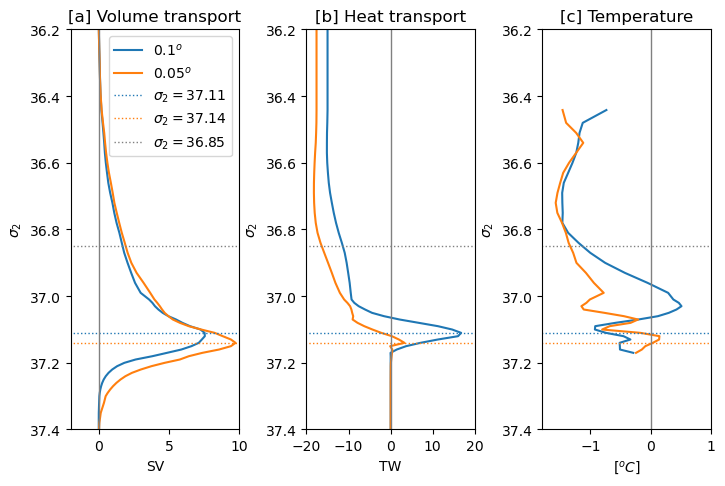

In [ ]:
plt.figure(figsize=(8, 5))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(1,3,1)
plt.plot(MT01.mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT01.rho2_l[::-1]-1000, color='tab:blue',label=r"$0.1^o$")
plt.plot(MT005.mean('time').sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT005.rho2_l[::-1]-1000,color='tab:orange', label=r"$0.05^o$")
plt.plot([-5,15],[37.11,37.11],':',color='tab:blue',lw=1,label=r"$\sigma_2=37.11$")
plt.plot([-5,15],[37.14,37.14],':',color='tab:orange',lw=1,label=r"$\sigma_2=37.14$")
plt.plot([-5,15],[36.85,36.85],':',color='grey',lw=1,label=r"$\sigma_2=36.85$")

plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('SV'),plt.ylabel(r"$\sigma_2$");plt.title('[a] Volume transport')
plt.ylim(37.4,36.2); plt.xlim(-2,10)
plt.legend()

plt.subplot(1,3,2)
plt.plot(HTρ01bin.sum('lon_bin_midpoints')[::-1].cumsum()/1e12,\
         HTρ01bin.rho2_l[::-1], color='tab:blue', label=r"$0.1^o$")
plt.plot(HTρ005bin.sum('lon_bin_midpoints')[::-1].cumsum()/1e12,\
         HTρ005bin.rho2_l[::-1], color='tab:orange', label=r"$0.05^o$")
plt.plot([-50,20],[37.11,37.11],':',color='tab:blue',lw=1)
plt.plot([-50,20],[37.14,37.14],':',color='tab:orange',lw=1)
plt.plot([-50,20],[36.85,36.85],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('TW'),plt.ylabel(r"$\sigma_2$");plt.title('[b] Heat transport')
plt.ylim(37.4,36.2);plt.xlim(-20,20)

plt.subplot(1,3,3)
plt.plot(Tempρ01bin.weighted(Vol01ρbinnedd.fillna(0)).mean('lon_bin_midpoints')[::-1],\
         Tempρ01bin.rho2_l[::-1], color='tab:blue', label=r"$0.1^o$")
plt.plot(Tempρ005bin.weighted(Vol005ρbinnedd.fillna(0)).mean('lon_bin_midpoints')[::-1],\
         Tempρ005bin.rho2_l[::-1], color='tab:orange', label=r"$0.05^o$")
plt.plot([-5,15],[37.11,37.11],':',color='tab:blue',lw=1)
plt.plot([-5,15],[37.14,37.14],':',color='tab:orange',lw=1)
plt.plot([-5,15],[36.85,36.85],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel(r"$[^oC]$"),plt.ylabel(r"$\sigma_2$");plt.title('[c] Temperature')
plt.ylim(37.4,36.2);plt.xlim(-1.8,1)

The heat transports in sigma coordinates above show us a few things

1- Even tho we have stronger DSW outflow in the higher resolution, the northward heat transport associated with it is lower. That could be achieved by having colder DSW in panan005. Indeed, we see that DSW in panan005 seem to be substantially colder than panan01

2- CDW heat transport towards the shelf actually decreases in higher resolution (Notice the plot has heat transport integrated upwards). That is hard to understand. But perhaps a colder DSW mixes with CDW along the slope, progressively decreasing CDW temperature. Indeed the maximum of the average CDW temperature in panan005 (~0.2 C) is smaller than in panan01 (~0.8 C)


We want to calculate the CDW heat transport in the simulations, along the contour, so we can diagnose wehre most of these changes happen. In order to do that we need to have a reasonable definition of $\sigma_2$ values that separate the CDW/DSW and CDW/AASW.


In Morrisson 2020, Adele used the peaking offshore transport value to define the $\sigma_1$ of the DSW/CDW front. For the CDW/AASW front, a TS/age diagram was plotted, and a $\sigma_1$ layer that coherently separate the majority of the warmer waters on the shelf was used (in the paper case, it was $\sigma_1$=32.4).
 Let's create a TS/age diagram with the data from the last year of panan01  on the shelf to check that.

Importing required modules for TS diagram

In [ ]:
import gsw
from xhistogram.xarray import histogram as xhistogram
import warnings
warnings.simplefilter('ignore')

## plotting
import matplotlib.colors as colors

Definitions and arguments

In [ ]:
expt_args = {
    "mom6-01": {
        "expt": "panant-01-zstar-ACCESSyr2",
        "start_time": "2000-01-01",
        "end_time": "2000-12-31"},
    "mom6-005": {
        "expt": "panant-005-zstar-ACCESSyr2",
        "start_time": "2000-01-01",
        "end_time": "2000-12-31"}}

vars_args = {
    "mom6": {
        "var_temp": 'thetao',
        "var_salt": 'so',
        "var_area": 'areacello'}}

lat=lat_slice
lon=slice(-280,80)
def gsw_SA_from_SP(salt, lon_name):
    """function to convert practical salinity to absolute salinity
    using the Gibbs SeaWater (GSW) Oceanographic Toolbox of TEOS-10
    (https://teos-10.github.io/GSW-Python/)
    
    input:
        -salt: practical salinity (array)
        -lon_name: name of the longitude (str)
    output:
        -salt_abs: absolute salinity (array)
    """
    pres = gsw.p_from_z(-salt.cf['vertical'], salt.cf['latitude'])
    salt_abs = gsw.SA_from_SP(salt, pres, salt[lon_name], salt.cf['latitude'])
    salt_abs.attrs = {'units': 'Absolute Salinity (g/kg)'}
    return salt_abs

def load_salinity(model):
    salt = cc.querying.getvar(
        variable=vars_args[model[0:4]].get('var_salt'), session=session, frequency='1 monthly',\
        chunks={'xh':'100gb','yh':'100gb'},\
        **expt_args[model])
    lon_name = salt.cf['longitude'].name
    # select longitude, latitude range and time
    salt = salt.cf.sel(longitude=lon).cf.sel(
        latitude=lat, time=slice(expt_args[model].get('start_time'),
                                 expt_args[model].get('end_time')))
    # convert from practical to absolute salinity
    salt = gsw_SA_from_SP(salt, lon_name).mean('time')
    return salt

def load_temperature(model,salt):
    temp = cc.querying.getvar(
        variable=vars_args[model[0:4]].get('var_temp'), session=session, frequency='1 monthly',\
        chunks={'xh':'100gb','yh':'100gb'},\
        **expt_args[model])
    # select longitude, latitude range and time
    temp = temp.cf.sel(longitude=lon).cf.sel(
        latitude=lat, time=slice(expt_args[model].get('start_time'),
                                 expt_args[model].get('end_time')))

    # convert potential to conservative temperature
    temp = gsw.conversions.CT_from_pt(salt, temp).mean('time')
    temp.name = 'temp'
    temp.attrs = {'units': 'Conservative temperature (°C)'}
    return temp

def load_grid_areas(model):
    if model == "mom6-01": 
        area=xr.open_dataset('/g/data/ik11/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output000/19910101.ocean_static.nc')
        area=area.areacello
    elif model == "mom6-005": 
        area=xr.open_dataset('/g/data/ik11/outputs/mom6-panan/panant-005-zstar-ACCESSyr2/output000/19910101.ocean_static.nc')
        area=area.areacello
    # area = cc.querying.getvar(
    #     variable=vars_args[model[0:4]].get('var_area'), session=session,ncfile='%ocean_static%', n=1,
    #     **expt_args[model])
    # select longitude and latitude range
    area = area.cf.sel(longitude=lon).cf.sel(
        latitude=lat)
    return area

def compute_TS_bins(salt, temp, area):
    
    salt_bins = np.arange(np.floor(salt.min().values), np.ceil(salt.max().values), 0.1)
    temp_bins = np.arange(np.floor(temp.min().values), np.ceil(temp.max().values)+0.5, 0.5)
    # for density contours in TS diagram
    temp_bins_mesh,salt_bins_mesh = np.meshgrid(temp_bins, salt_bins)
    TS_density = gsw.density.sigma2(salt_bins_mesh, temp_bins_mesh)
    # volume of grid cells to account for varying grid cells especially in the vertical
    vol = (temp.cf['vertical'] * area)

    # 2D histogram of temperature and salinity weighted by volume
    # TS_hist = xhistogram(
    #     temp, salt, bins=(temp_bins, salt_bins), weights=vol)
    # TS_hist = TS_hist.where(TS_hist != 0).compute()
    return TS_density, salt_bins_mesh, temp_bins_mesh 

In [ ]:
#Calculating TS diagram for panan01

#importing data
model = 'mom6-01'  
salt01 = load_salinity(model)
temp01 = load_temperature(model,salt01)
area01 = load_grid_areas(model)

#Masking off-shelf regions
salt01=salt01.where(P01_maskd>=0)
temp01=temp01.where(P01_maskd>=0)
area01=area01.where(P01_maskd>=0)

#producing diagram
TS_density01, salt_bins_mesh01, temp_bins_mesh01 = compute_TS_bins(salt01, temp01, area01)

In [ ]:
#Calculating TS diagram for panan005

# #importing data
model = 'mom6-005'  
salt005 = load_salinity(model)
temp005 = load_temperature(model,salt005)
area005 = load_grid_areas(model)

#Masking off-shelf regions
salt005=salt005.where(P005_maskd>=0)
temp005=temp005.where(P005_maskd>=0)
area005=area005.where(P005_maskd>=0)

# #producing diagram
TS_density005, salt_bins_mesh005, temp_bins_mesh005 = compute_TS_bins(salt005, temp005, area005)

2024-01-18 09:41:41,052 - distributed.spill - ERROR - Spill to disk failed; keeping data in memory
Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/spill.py", line 124, in _handle_errors
    yield
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/spill.py", line 199, in evict
    _, _, weight = self.fast.evict()
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/zict/common.py", line 127, in wrapper
    return func(*args, **kwargs)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/zict/lru.py", line 227, in evict
    cb(key, value)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/zict/buffer.py", line 139, in fast_to_slow
    self.slow[key] = value
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/

In [ ]:
salt005=salt005.compute()
temp005=temp005.compute()
salt01=salt01.compute()
temp01=temp01.compute()

2024-01-18 09:51:21,069 - distributed.spill - ERROR - Spill to disk failed; keeping data in memory
Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/spill.py", line 124, in _handle_errors
    yield
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/spill.py", line 199, in evict
    _, _, weight = self.fast.evict()
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/zict/common.py", line 127, in wrapper
    return func(*args, **kwargs)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/zict/lru.py", line 227, in evict
    cb(key, value)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/zict/buffer.py", line 139, in fast_to_slow
    self.slow[key] = value
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/

2024-01-18 09:51:28,960 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 28.77 GiB -- Worker memory limit: 35.97 GiB
2024-01-18 09:51:29,300 - distributed.spill - ERROR - Spill to disk failed; keeping data in memory
Traceback (most recent call last):
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/spill.py", line 124, in _handle_errors
    yield
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/distributed/spill.py", line 199, in evict
    _, _, weight = self.fast.evict()
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/zict/common.py", line 127, in wrapper
    return func(*args, **kwargs)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/zict/lru.py", line 227, in evict
    cb(key, value)
  File "/g/data/hh5/public/apps/miniconda3/envs/analysis3-2

In [ ]:
## Getting the age in each model cell
#for Panan01
age01 = cc.querying.getvar(exp01, 'agessc', session,start_time=start_time, end_time=end_time,ncfile='%month_z%',\
                           chunks={'xh':'100gb','yh':'100gb'}).isel(time=-1).sel(yh=lat_range).compute()
age01=age01.where(P01_maskd>=0)
#for Panan005
age005 = cc.querying.getvar(exp005, 'agessc', session,start_time=start_time, end_time=end_time,ncfile='%month_z%',\
                           chunks={'xh':'100gb','yh':'100gb'}).isel(time=-1).sel(yh=lat_range).compute()
age005=age005.where(P005_maskd>=0)


extracting points along the isobath

In [ ]:
csalt005 = salt005.sel(xh=meanp005_HT.lon_along_contour,yh=meanp005_HT.lat_along_contour, method='nearest')
ctemp005 = temp005.sel(xh=meanp005_HT.lon_along_contour,yh=meanp005_HT.lat_along_contour, method='nearest')
cage005 = age005.sel(xh=meanp005_HT.lon_along_contour,yh=meanp005_HT.lat_along_contour, method='nearest')
csalt01 = salt01.sel(xh=meanp01_HT.lon_along_contour,yh=meanp01_HT.lat_along_contour, method='nearest')
ctemp01 = temp01.sel(xh=meanp01_HT.lon_along_contour,yh=meanp01_HT.lat_along_contour, method='nearest')
cage01 = age01.sel(xh=meanp01_HT.lon_along_contour,yh=meanp01_HT.lat_along_contour, method='nearest')

#christinas contour
cage01binc = age01.sel(xh=MT01.lon,yh=MT01.lat, method='nearest').isel(z_l=slice(0,51))
cage005binc = age005.sel(xh=MT005.lon,yh=MT005.lat, method='nearest').isel(z_l=slice(0,51))

In [ ]:
# ### getting values along the isotherm for Christina contour
T01cris = T01.sel(xh=MT01.lon,yh=MT01.lat, method='nearest')
T005cris = T005.sel(xh=MT005.lon,yh=MT005.lat, method='nearest')

#now along isobaths
T01ρcris  = Parallel(n_jobs=-1)(delayed(depthtosigmac)(sigma01c,T01cris.isel(z_l=slice(0,51)) ,HTρn,n) for n in range(0,np.size(sigma01c.contour_index)))
T005ρcris = Parallel(n_jobs=-1)(delayed(depthtosigmac)(sigma005c,T005cris.isel(z_l=slice(0,51)),HTρn,n) for n in range(0,np.size(sigma005c.contour_index)))


/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: Ru

/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: Ru

In [ ]:
#
T01ρcrisd=MT01mean.copy()
T01ρcrisd.values=np.transpose(T01ρcris,[1,0])
T005ρcrisd=MT005mean.copy()
T005ρcrisd.values=np.transpose(T005ρcris,[1,0])

In [ ]:
cageρbin01 = Parallel(n_jobs=-1)(delayed(depthtosigmac)(sigma01c,cage01binc,HTρn,n) for n in range(0,np.size(sigma01c.contour_index)))
cageρbin005 = Parallel(n_jobs=-1)(delayed(depthtosigmac)(sigma005c,cage005binc,HTρn,n) for n in range(0,np.size(sigma005c.contour_index)))


/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:5: Ru

In [ ]:
#Transformingbinned age of mass transports from christina in xarray
cageρbin01d=MT01mean.copy()
cageρbin01d.values=np.transpose(cageρbin01,[1,0])
cageρbin005d=MT005mean.copy()
cageρbin005d.values=np.transpose(cageρbin005,[1,0])

TS diagram

Text(0.5, 1.0, '[a] $0.005^o$')

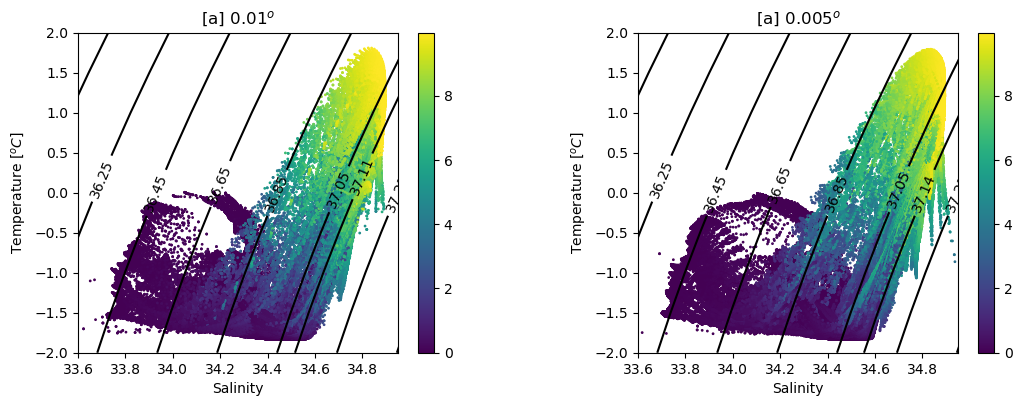

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)



#for panan01
plt.subplot(1,2,1)
plt.scatter(csalt01,ctemp01,s=1,c=cage01,cmap='viridis')
plt.colorbar()
plt.xlim(33.6,34.95)

levels01=np.arange(np.floor(TS_density01.min())+0.05,
                                  np.ceil(TS_density01.max()), .2)
levels01=np.sort(np.append(levels01,37.11)) #adding the level used to define the DSW in panan01
cs01 = plt.contour(
    salt_bins_mesh01, temp_bins_mesh01, TS_density01, colors='black',
                 levels=levels01)
plt.clabel(cs01, inline=True);
plt.xlabel('Salinity'); plt.ylabel(r"Temperature [$^oC$]")
plt.title(r"[a] $0.01^o$")


#for panan01
plt.subplot(1,2,2)
plt.scatter(csalt005,ctemp005,s=1,c=cage005,cmap='viridis')
plt.colorbar()
plt.xlim(33.6,34.95)

levels005=np.arange(np.floor(TS_density005.min())+0.05,
                                  np.ceil(TS_density005.max()), .2)
levels005=np.sort(np.append(levels005,37.14)) #adding the level used to define the DSW in panan005
cs005 = plt.contour(
    salt_bins_mesh005, temp_bins_mesh005, TS_density005, colors='black',
                 levels=levels005)
plt.clabel(cs005, inline=True);
plt.xlabel('Salinity'); plt.ylabel(r"Temperature [$^oC$]")
plt.title(r"[a] $0.005^o$")

**Notice** *that using soley density to define the CDW would be misleading, as we have a very high concentration of super cold waters (Likely Winter Waters) on the smae density range. So we will use a multifactor approach to define the waters*

-**DSW**

DSW[$0.1^o$], waters with $\sigma_2>37.14$

DSW[$0.05^o$], waters with $\sigma_2>37.11$

-**CDW**[$0.1^o$ or $0.05^o$], waters with $\sigma_2>37.85$, and $age>4$ years (North source)

-**WW**[$0.1^o$ or $0.05^o$], waters with $\sigma_2>37.85$, and $age<=4$ years

-**AASW**[$0.1^o$ or $0.05^o$], waters with $\sigma_2<37.85$,




Another thing we can see is that indeed, it seems like panan005 have colder DSW, as it seems to have temperatures going down to the freezing point. That agrees with the lower heat transport from DSW

Transforming the age in bin space

In [ ]:
#getting the age at the binned points
cage01bin = age01.sel(xh=meanp01_HT.lon_bin_midpoints,yh=meanp01_HT.lat_bin_midpoints, method='nearest')
cage005bin = age01.sel(xh=meanp005_HT.lon_bin_midpoints,yh=meanp005_HT.lat_bin_midpoints, method='nearest')

#transforming into density space
cageρbin01 = Parallel(n_jobs=-1)(delayed(depthtosigmaTempbin)(meansigma01binnedd,cage01bin.isel(z_l=slice(0,51)),HTρn,n) for n in range(0,np.size(meanp01_HT.lon_bin_midpoints)))
cageρbin005 = Parallel(n_jobs=-1)(delayed(depthtosigmaTempbin)(meansigma005binnedd,cage005bin.isel(z_l=slice(0,51)),HTρn,n) for n in range(0,np.size(meanp01_HT.lon_bin_midpoints)))

#Transforming age in xarray
cage01ρbinnedd=HTρ01bin.copy()
cage01ρbinnedd.values=cageρbin01
cage005ρbinnedd=HTρ005bin.copy()
cage005ρbinnedd.values=cageρbin005

/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/109698371.py:78: RuntimeWarning: Mean of empty slice
/scratch/g40/wf4500/tmp/ipykernel_1049851/10969837

Text(0.5, 1.0, '[d] DSW Heat transport')

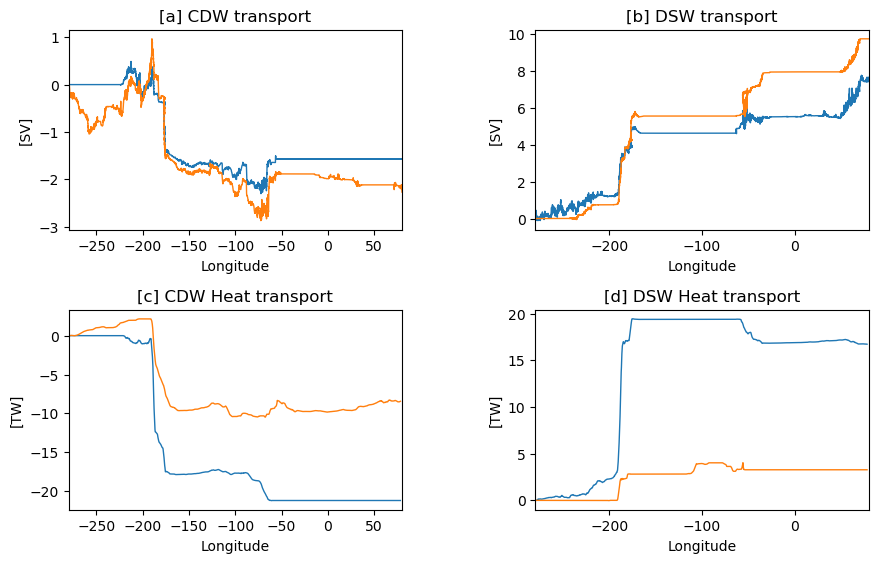

In [ ]:
plt.figure(figsize=(10, 6))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

CDW_slice01=slice(1036.85,1037.11)
CDW_slice005=slice(1036.85,1037.14)
DSW_slice01=slice(1037.11,1037.5)
DSW_slice005=slice(1037.14,1037.5)
HCDW_slice01=slice(36.85,37.11)
HCDW_slice005=slice(36.85,37.14)
HDSW_slice01=slice(37.11,37.5)
HDSW_slice005=slice(37.14,37.5)

cdwyr=2 # for a age criteria
cdwtemp=0 # for a temperature criteria

HCDW01=HTρ01bin.where(Tempρ01bin>cdwtemp).sel(rho2_l=HCDW_slice01).sum('rho2_l')
HCDW005=HTρ005bin.where(Tempρ005bin>cdwtemp).sel(rho2_l=HCDW_slice005).sum('rho2_l')
SCDW01=STρ01bin.where(Tempρ01bin>cdwtemp).sel(rho2_l=HCDW_slice01).sum('rho2_l')
SCDW005=STρ005bin.where(Tempρ005bin>cdwtemp).sel(rho2_l=HCDW_slice005).sum('rho2_l')

HDSW01=HTρ01bin.sel(rho2_l=HDSW_slice01).sum('rho2_l')
HDSW005=HTρ005bin.sel(rho2_l=HDSW_slice005).sum('rho2_l')

#cageρbin01d
CDW01=MT01.mean('time').where(T01ρcrisd>cdwtemp).sel(rho2_l=CDW_slice01).sum('rho2_l').vol_trans_across_contour
CDW005=MT005.mean('time').where(T005ρcrisd>cdwtemp).sel(rho2_l=CDW_slice005).sum('rho2_l').vol_trans_across_contour
DSW01=MT01.mean('time').sel(rho2_l=DSW_slice01).sum('rho2_l').vol_trans_across_contour
DSW005=MT005.mean('time').sel(rho2_l=DSW_slice005).sum('rho2_l').vol_trans_across_contour



#for panan01
plt.subplot(2,2,1)
plt.plot(MT01.lon,\
         CDW01.cumsum(), color='tab:blue',lw=1,label=r"$0.1^o$")
plt.plot(MT005.lon,\
         CDW005.cumsum(), color='tab:orange',lw=1,label=r"$0.05^o$")
plt.xlim(-280,80);plt.xlabel('Longitude');plt.ylabel('[SV]')
plt.title('[a] CDW transport')

plt.subplot(2,2,2)
plt.plot(MT01.lon,\
         DSW01.cumsum(), color='tab:blue',lw=1,label=r"$0.1^o$")
plt.plot(MT005.lon,\
         DSW005.cumsum(), color='tab:orange',lw=1,label=r"$0.05^o$")
plt.xlim(-280,80);plt.xlabel('Longitude');plt.ylabel('[SV]')
plt.title('[b] DSW transport')


plt.subplot(2,2,3)
plt.plot(meanp01_HT.lon_bin_midpoints,\
         HCDW01.cumsum()/1e12, color='tab:blue',lw=1,label=r"$0.1^o$")
plt.plot(meanp005_HT.lon_bin_midpoints,\
         HCDW005.cumsum()/1e12, color='tab:orange',lw=1,label=r"$0.05^o$")
plt.xlim(-280,80);plt.xlabel('Longitude');plt.ylabel('[TW]')
plt.title('[c] CDW Heat transport')

plt.subplot(2,2,4)
plt.plot(meanp01_HT.lon_bin_midpoints,\
         HDSW01.cumsum()/1e12, color='tab:blue',lw=1,label=r"$0.1^o$")
plt.plot(meanp005_HT.lon_bin_midpoints,\
         HDSW005.cumsum()/1e12, color='tab:orange',lw=1,label=r"$0.05^o$")
plt.xlim(-280,80);plt.xlabel('Longitude');plt.ylabel('[TW]')
plt.title('[d] DSW Heat transport')

In [ ]:
#mean CDW temperatures on each simulation
meanCDWtemp01=Tempρ01bin.where(Tempρ01bin>cdwtemp).sel(rho2_l=HCDW_slice01).weighted(Vol01ρbinnedd.fillna(0)).mean(skipna='True')
meanCDWtemp005=Tempρ005bin.where(Tempρ005bin>cdwtemp).sel(rho2_l=HCDW_slice005).weighted(Vol005ρbinnedd.fillna(0)).mean(skipna='True')
meanDSWtemp01=Tempρ01bin.sel(rho2_l=HDSW_slice01).weighted(Vol01ρbinnedd.fillna(0)).mean(skipna='True')
meanDSWtemp005=Tempρ005bin.sel(rho2_l=HDSW_slice005).weighted(Vol005ρbinnedd.fillna(0)).mean(skipna='True')


print('Mean CDW temperature on Panan-0.1° is '  + str(int(meanCDWtemp01.values*1000)/1000) + '°C \n' +\
      'Mean CDW temperature on Panan-0.05° is ' + str(int(meanCDWtemp005.values*1000)/1000) + '°C\n' +\
       'Mean DSW temperature on Panan-0.1° is '  + str(int(meanDSWtemp01.values*1000)/1000) + '°C \n' +\
       'Mean DSW temperature on Panan-0.05° is '  + str(int(meanDSWtemp005.values*1000)/1000) + '°C')

Mean CDW temperature on Panan-0.1° is 1.074°C 
Mean CDW temperature on Panan-0.05° is 0.617°C
Mean DSW temperature on Panan-0.1° is -0.493°C 
Mean DSW temperature on Panan-0.05° is 0.023°C


Ok, so it seems that there is a few things happening here. 

**First**,in the Ross Sea we see that even tho we have more DSW outgoing, the heat being exported by DSW  decreases a lot. This agrees with the DSW having colder temperatures on panan005.

**Second**, CDW inflow in the Ross sea does increase, and using the  temperature criteria, it seems that he heat transport associated with it increases too.


Worrying results: In East Antarctica, it seems that we find an increase in CDW inflow, but HT is northward. WHich makes not much sense. Perhaps this has to do with the fact the we use different contours for the HT and MT. Lets try to analyze different regions for better depiction of water masses and understanding the processes.


(-1.0, 10.0)

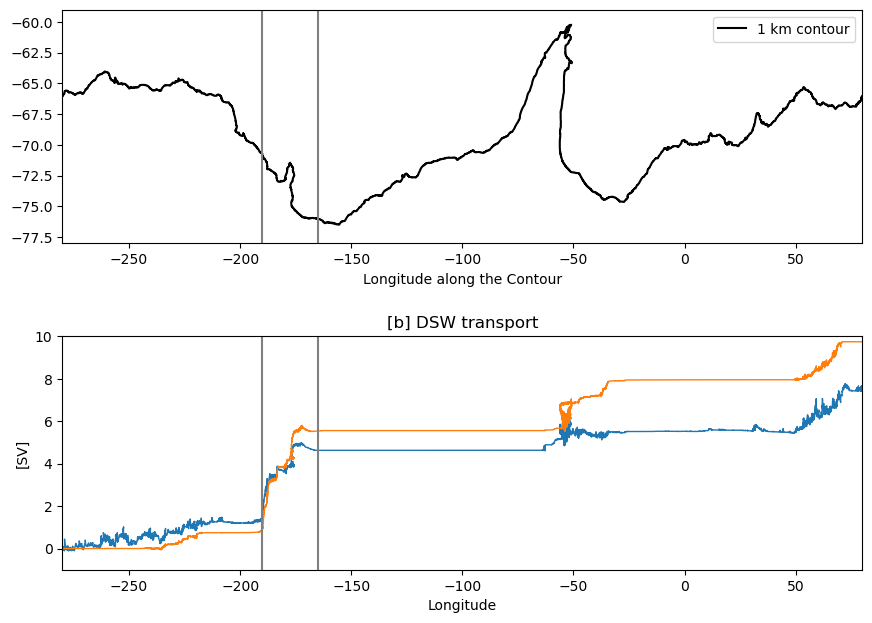

In [ ]:
plt.figure(figsize=(10, 7))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

plt.subplot(2,1,1)
plt.plot(p005_ST.isel(time=0).lon_along_contour.drop('time'),
         p005_ST.isel(time=0).lat_along_contour.drop('time'), color='black',label='1 km contour')
plt.plot([-190,-190],[-80,-50],color='grey')
plt.plot([-165,-165],[-80,-50],color='grey')
plt.xlabel('Longitude along the Contour'); plt.xlim(-280,80); plt.ylim(-78,-59)
plt.legend()

plt.subplot(2,1,2)
plt.plot(MT01.lon,\
         DSW01.cumsum(), color='tab:blue',lw=1,label=r"$0.1^o$")
plt.plot(MT005.lon,\
         DSW005.cumsum(), color='tab:orange',lw=1,label=r"$0.05^o$")
plt.plot([-190,-190],[-1,10],color='grey')
plt.plot([-165,-165],[-1,10],color='grey')
plt.xlim(-280,80);plt.xlabel('Longitude');plt.ylabel('[SV]')
plt.title('[b] DSW transport'); plt.ylim(-1,10)

### East Antarctica [280W 190W]

In [ ]:
#Extracting T,S and age in East Antarctica

#panan01
EAcsalt01 = csalt01.isel(z_l=slice(0,51)).where(meanp01_HT.lon_along_contour<-190).compute()
EActemp01 = ctemp01.isel(z_l=slice(0,51)).where(meanp01_HT.lon_along_contour<-190).compute()
EAcage01 = cage01.isel(z_l=slice(0,51)).where(meanp01_HT.lon_along_contour<-190).compute()

#panan005
EAcsalt005 = csalt005.isel(z_l=slice(0,51)).where(meanp005_HT.lon_along_contour<-190).compute()
EActemp005 = ctemp005.isel(z_l=slice(0,51)).where(meanp005_HT.lon_along_contour<-190).compute()
EAcage005 = cage005.isel(z_l=slice(0,51)).where(meanp005_HT.lon_along_contour<-190).compute()

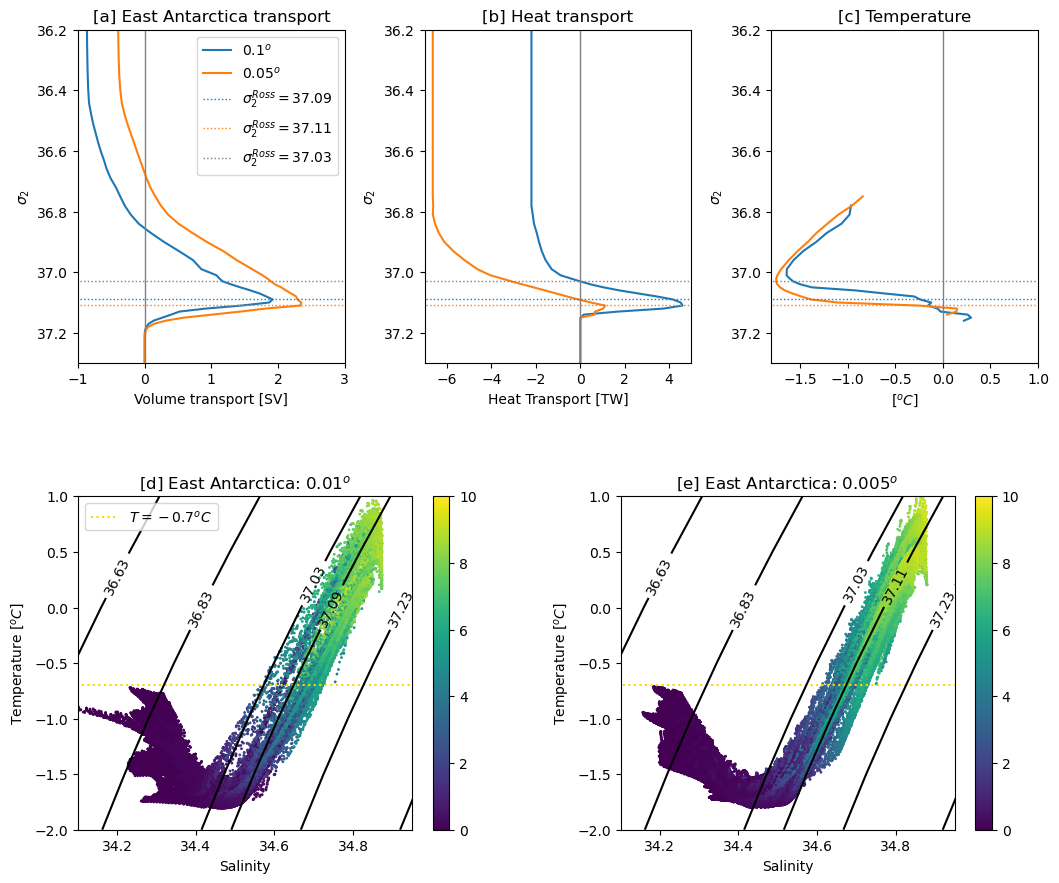

In [ ]:
plt.figure(figsize=(12, 10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.3, 
                    hspace=0.4)

plt.subplot(2,3,1)
plt.plot(MT01.mean('time').where(MT01.lon<-190).sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT01.rho2_l[::-1]-1000, color='tab:blue',label=r"$0.1^o$")
plt.plot(MT005.mean('time').where(MT005.lon<-190).sum('contour_index').vol_trans_across_contour[::-1].cumsum(),\
         MT005.rho2_l[::-1]-1000,color='tab:orange', label=r"$0.05^o$")
plt.plot([-5,15],[37.09,37.09],':',color='tab:blue',lw=1,label=r"$\sigma_2^{Ross}=37.09$")
plt.plot([-5,15],[37.11,37.11],':',color='tab:orange',lw=1,label=r"$\sigma_2^{Ross}=37.11$")
plt.plot([-5,15],[37.03,37.03],':',color='grey',lw=1,label=r"$\sigma_2^{Ross}=37.03$")
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('Volume transport [SV]'),plt.ylabel(r"$\sigma_2$");plt.title('[a] East Antarctica transport')
plt.ylim(37.3,36.2); plt.xlim(-1,3)
plt.legend()

plt.subplot(2,3,2)
plt.plot(HTρ01bin.where(HTρ01bin.lon_bin_midpoints<-190).sum('lon_bin_midpoints')[::-1].cumsum()/1e12,\
         HTρ01bin.rho2_l[::-1], color='tab:blue', label=r"$0.1^o$")
plt.plot(HTρ005bin.where(HTρ005bin.lon_bin_midpoints<-190).sum('lon_bin_midpoints')[::-1].cumsum()/1e12,\
         HTρ005bin.rho2_l[::-1], color='tab:orange', label=r"$0.05^o$")
plt.plot([-50,20],[37.09,37.09],':',color='tab:blue',lw=1)
plt.plot([-50,20],[37.11,37.11],':',color='tab:orange',lw=1)
plt.plot([-50,20],[37.03,37.03],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel('Heat Transport [TW]'),plt.ylabel(r"$\sigma_2$");plt.title('[b] Heat transport')
plt.ylim(37.3,36.2);plt.xlim(-7,5)

plt.subplot(2,3,3)
plt.plot(Tempρ01bin.where(Tempρ01bin.lon_bin_midpoints<-190).weighted(Vol01ρbinnedd.fillna(0)).mean('lon_bin_midpoints')[::-1],\
         Tempρ01bin.rho2_l[::-1], color='tab:blue', label=r"$0.1^o$")
plt.plot(Tempρ005bin.where(Tempρ005bin.lon_bin_midpoints<-190).weighted(Vol005ρbinnedd.fillna(0)).mean('lon_bin_midpoints')[::-1],\
         Tempρ005bin.rho2_l[::-1], color='tab:orange', label=r"$0.05^o$")
plt.plot([-5,15],[37.09,37.09],':',color='tab:blue',lw=1)
plt.plot([-5,15],[37.11,37.11],':',color='tab:orange',lw=1)
plt.plot([-5,15],[37.03,37.03],':',color='grey',lw=1)
plt.plot([0,0],[30,40],color='grey',linewidth=1)
plt.xlabel(r"$[^oC]$"),plt.ylabel(r"$\sigma_2$");plt.title('[c] Temperature')
plt.ylim(37.3,36.2);plt.xlim(-1.8,1)


plt.subplot(2,2,3)
plt.scatter(EAcsalt01,EActemp01,s=1,c=EAcage01,cmap='viridis',vmin=0,vmax=10)
plt.colorbar()
plt.xlim(34.1,34.95);plt.ylim(-2,1)

levels01=np.arange(np.floor(TS_density01.min())+0.03,
                                  np.ceil(TS_density01.max()), .2)
levels01=np.sort(np.append(levels01,37.09)) #adding the level used to define the DSW in panan01
plt.plot([32,40],[-0.7,-0.7],':',color='gold',label=r"$T=-0.7^oC$")
cs01 = plt.contour(
    salt_bins_mesh01, temp_bins_mesh01, TS_density01, colors='black',
                 levels=levels01)
plt.clabel(cs01, inline=True);
plt.xlabel('Salinity'); plt.ylabel(r"Temperature [$^oC$]")
plt.title(r"[d] East Antarctica: $0.01^o$")
plt.legend()

plt.subplot(2,2,4)
plt.scatter(EAcsalt005,EActemp005,s=1,c=EAcage005,cmap='viridis',vmin=0,vmax=10)
plt.colorbar()
plt.xlim(34.1,34.95);plt.ylim(-2,1)
plt.plot([32,40],[-0.7,-0.7],':',color='gold')
levels005=np.arange(np.floor(TS_density005.min())+0.03,
                                  np.ceil(TS_density005.max()), .2)
levels005=np.sort(np.append(levels005,37.11)) #adding the level used to define the DSW in panan005
cs005 = plt.contour(
    salt_bins_mesh005, temp_bins_mesh005, TS_density005, colors='black',
                 levels=levels005)
plt.clabel(cs005, inline=True);
plt.xlabel('Salinity'); plt.ylabel(r"Temperature [$^oC$]")
plt.title(r"[e] East Antarctica: $0.005^o$")

plt.savefig(figdir+'EA_sigmaDef.png',dpi=300,bbox_inches='tight')

For East Antarctica it seems that...


**DSW upper density boundaries:**

$\sigma_2^{0.1}>37.09\ Kg\ m^{-3}$ 

$\sigma_2^{0.05}>37.11\ Kg\ m^{-3}$ 


**CDW:**

$\sigma_2=37.03\ Kg\ m^{-3}$ , and $T>-0.7^oC$ serves as a good upper density boundary for CDW


Notice that this is yet no perfect as there is some penetration of winter waters in the CDW definition 



In [ ]:
# the Volumes of the and heat transports definitions for East Antarctic Will then be

eaCDW_slice01=slice(1037.03,1037.09)
eaCDW_slice005=slice(1037.03,1037.11)
eaDSW_slice01=slice(1037.09,1037.5)
eaDSW_slice005=slice(1037.11,1037.5)
eaHCDW_slice01=slice(37.03,37.09)
eaHCDW_slice005=slice(37.03,37.11)
eaHDSW_slice01=slice(37.09,37.5)
eaHDSW_slice005=slice(37.11,37.5)

cdwyr=2 # for testing a age criteria
cdwtemp=-0.7 # for a temperature criteria

#### CDW heat transport
# total HT and
eaHCDW01=HTρ01bin.where(HTρ01bin.lon_bin_midpoints<-190).where(Tempρ01bin>cdwtemp).sel(rho2_l=eaHCDW_slice01).sum('rho2_l')
eaHCDW005=HTρ005bin.where(HTρ005bin.lon_bin_midpoints<-190).where(Tempρ005bin>cdwtemp).sel(rho2_l=eaHCDW_slice005).sum('rho2_l')
eaHCDW01z=HTρ01bin.where(HTρ01bin.lon_bin_midpoints<-190).where(Tempρ01bin>cdwtemp).sel(rho2_l=eaHCDW_slice01)
eaHCDW005z=HTρ005bin.where(HTρ005bin.lon_bin_midpoints<-190).where(Tempρ005bin>cdwtemp).sel(rho2_l=eaHCDW_slice005)
# frontal HT and
eaHCDW01_f=HTρ01bin_f.where(HTρ01bin_f.lon_bin_midpoints<-190).where(Tempρ01bin>cdwtemp).sel(rho2_l=eaHCDW_slice01).sum('rho2_l')
eaHCDW005_f=HTρ005bin_f.where(HTρ005bin_f.lon_bin_midpoints<-190).where(Tempρ005bin>cdwtemp).sel(rho2_l=eaHCDW_slice005).sum('rho2_l')
eaHCDW01z_f=HTρ01bin_f.where(HTρ01bin_f.lon_bin_midpoints<-190).where(Tempρ01bin>cdwtemp).sel(rho2_l=eaHCDW_slice01)
eaHCDW005z_f=HTρ005bin_f.where(HTρ005bin_f.lon_bin_midpoints<-190).where(Tempρ005bin>cdwtemp).sel(rho2_l=eaHCDW_slice005)
# total zc and
eaHCDW01_zc=HTρ01bin_zc.where(HTρ01bin_zc.lon_bin_midpoints<-190).where(Tempρ01bin>cdwtemp).sel(rho2_l=eaHCDW_slice01).sum('rho2_l')
eaHCDW005_zc=HTρ005bin_zc.where(HTρ005bin_zc.lon_bin_midpoints<-190).where(Tempρ005bin>cdwtemp).sel(rho2_l=eaHCDW_slice005).sum('rho2_l')
eaHCDW01z_zc=HTρ01bin_zc.where(HTρ01bin_zc.lon_bin_midpoints<-190).where(Tempρ01bin>cdwtemp).sel(rho2_l=eaHCDW_slice01)
eaHCDW005z_zc=HTρ005bin_zc.where(HTρ005bin_zc.lon_bin_midpoints<-190).where(Tempρ005bin>cdwtemp).sel(rho2_l=eaHCDW_slice005)


#### CDW temperature
eaCDW01meanT= Tempρ01bin.where(Tempρ01bin.lon_bin_midpoints<-190).where(Tempρ01bin>cdwtemp).sel(rho2_l=eaHCDW_slice01).weighted(Vol01ρbinnedd).mean()
eaCDW005meanT = Tempρ005bin.where(Tempρ005bin.lon_bin_midpoints<-190).where(Tempρ005bin>cdwtemp).sel(rho2_l=eaHCDW_slice005).weighted(Vol005ρbinnedd).mean()
# #mean CDW temps
# eaCDW01meanT = eaCDWTempρ01bin.weighted(area01binned).mean()
# eaCDW005meanT = eaCDWTempρ005bin.weighted(area005binned).mean()
#### DSW temperature
eaDSW01meanT = Tempρ01bin.where(Tempρ01bin.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice01).weighted(Vol01ρbinnedd).mean()
eaDSW005meanT = Tempρ005bin.where(Tempρ005bin.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice005).weighted(Vol005ρbinnedd).mean()
# #mean DSW temps
# eaDSW01meanT = eaDSWTempρ01bin.mean()
# eaDSW005meanT = eaDSWTempρ005bin.mean()

### DSW heat transport
# total HT and
eaHDSW01=HTρ01bin.where(HTρ01bin.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice01).sum('rho2_l')
eaHDSW005=HTρ005bin.where(HTρ005bin.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice005).sum('rho2_l')
eaHDSW01z=HTρ01bin.where(HTρ01bin.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice01)
eaHDSW005z=HTρ005bin.where(HTρ005bin.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice005)
# total frontal transport and
eaHDSW01_f=HTρ01bin_f.where(HTρ01bin_f.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice01).sum('rho2_l')
eaHDSW005_f=HTρ005bin_f.where(HTρ005bin_f.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice005).sum('rho2_l')
# total ZC and
eaHDSW01_zc=HTρ01bin_zc.where(HTρ01bin_zc.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice01).sum('rho2_l')
eaHDSW005_zc=HTρ005bin_zc.where(HTρ005bin_zc.lon_bin_midpoints<-190).sel(rho2_l=eaHDSW_slice005).sum('rho2_l')

#Mass transports!
eaCDW01=MT01.mean('time').where(MT01.lon<-190).where(T01ρcrisd>cdwtemp).sel(rho2_l=eaCDW_slice01).sum('rho2_l').vol_trans_across_contour
eaCDW005=MT005.mean('time').where(MT005.lon<-190).where(T005ρcrisd>cdwtemp).sel(rho2_l=eaCDW_slice005).sum('rho2_l').vol_trans_across_contour
eaDSW01=MT01.mean('time').where(MT01.lon<-190).sel(rho2_l=eaDSW_slice01).sum('rho2_l').vol_trans_across_contour
eaDSW005=MT005.mean('time').where(MT005.lon<-190).sel(rho2_l=eaDSW_slice005).sum('rho2_l').vol_trans_across_contour




In [ ]:
eaDSW01meanT,eaDSW005meanT 

(<xarray.DataArray ()>
 array(-0.07076398),
 <xarray.DataArray ()>
 array(-0.01317203))

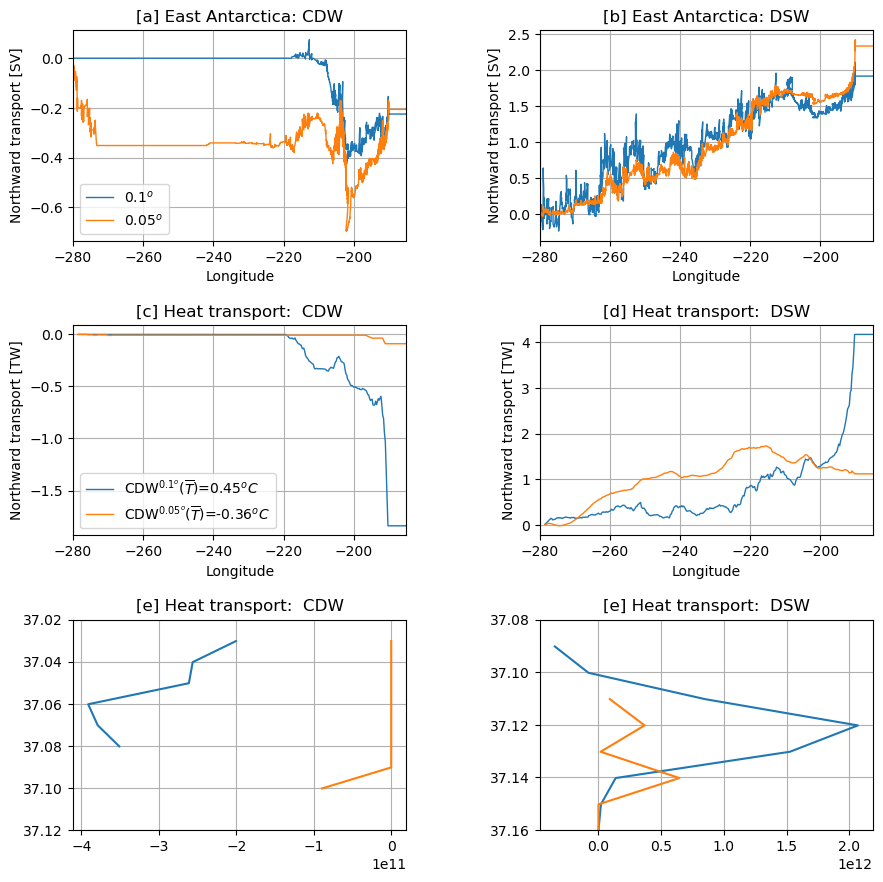

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)

#for panan01
plt.subplot(3,2,1)
plt.plot(MT01.lon,\
         eaCDW01.cumsum(), color='tab:blue',lw=1,label=r"$0.1^o$")
plt.plot(MT005.lon,\
         eaCDW005.cumsum(), color='tab:orange',lw=1,label=r"$0.05^o$")
plt.xlim(-280,-185);plt.xlabel('Longitude');plt.ylabel('Northward transport [SV]')
plt.title('[a] East Antarctica: CDW'); plt.grid()
plt.legend()

plt.subplot(3,2,2)
plt.plot(MT01.lon,\
         eaDSW01.cumsum(), color='tab:blue',lw=1,label=r"$0.1^o$")
plt.plot(MT005.lon,\
         eaDSW005.cumsum(), color='tab:orange',lw=1,label=r"$0.05^o$")
plt.xlim(-280,-185);plt.xlabel('Longitude');plt.ylabel('Northward transport [SV]')
plt.title('[b] East Antarctica: DSW'); plt.grid()


plt.subplot(3,2,3)
plt.plot(meanp01_HT.lon_bin_midpoints,\
         eaHCDW01.cumsum()/1e12, color='tab:blue',lw=1,label=r"CDW$^{0.1^o}$($\overline{T}$)=" +\
              str(float(int(eaCDW01meanT*100)/100)) + "$^oC$")
plt.plot(meanp005_HT.lon_bin_midpoints,\
         eaHCDW005.cumsum()/1e12, color='tab:orange',lw=1,label=r"CDW$^{0.05^o}$($\overline{T}$)=" +\
              str(float(int(eaCDW005meanT*100)/100)) + "$^oC$")
plt.xlim(-280,-185);plt.xlabel('Longitude');plt.ylabel('Northward transport [TW]')
plt.title('[c] Heat transport:  CDW')
plt.grid(); plt.legend()

plt.subplot(3,2,4)
plt.plot(meanp01_HT.lon_bin_midpoints,\
         eaHDSW01.cumsum()/1e12, color='tab:blue',lw=1,label=r"$0.1^o$")
plt.plot(meanp005_HT.lon_bin_midpoints,\
         eaHDSW005.cumsum()/1e12, color='tab:orange',lw=1,label=r"$0.05^o$")
plt.xlim(-280,-185);plt.xlabel('Longitude');plt.ylabel('Northward transport [TW]')
plt.title('[d] Heat transport:  DSW')
plt.grid()

plt.subplot(3,2,5)
plt.plot(eaHCDW01z.sum('lon_bin_midpoints'),eaHCDW01z.rho2_l,label=r"$0.1^o$")
plt.plot(eaHCDW005z.sum('lon_bin_midpoints'),eaHCDW005z.rho2_l,label=r"$0.05^o$")
plt.ylim(37.12,37.02)
plt.title('[e] Heat transport:  CDW'); plt.grid()


plt.subplot(3,2,6)
plt.plot(eaHDSW01z.sum('lon_bin_midpoints'),eaHDSW01z.rho2_l,label=r"$0.1^o$")
plt.plot(eaHDSW005z.sum('lon_bin_midpoints'),eaHDSW005z.rho2_l,label=r"$0.05^o$")
plt.ylim(37.16,37.08)
plt.title('[e] Heat transport:  DSW'); plt.grid()

**DSW**    

*[b,d]*: Our definitions show a modest increase in DSW outflow with resolution, mostly between $220^oW$ and $190^oW$. The heat export of the DSW decrease with resolution tho, which could be explained if DSW got substantially cold. **Check DSW temperatures along contour**

**CDW**

*[a]*: Three things appear here in terms of mass transport. [1] Increasing the resolution allows CDW to enter in the westernmost edge of the domain ~$280^oW$. [2] instead of purely southward CDW transport, we now have CDW northward transports at between $220^oW$ and $210^oW$. [3] The CDW Northward component in panan-$0.1^o$ east of $210^oW$ strengthens in panan-$0.05^o$. Slightly diminishng the total mass transport in the higher resolution.

*[c]*: Other 2 things are interesting here.[1]the Southward mass transport in ~$280^oW$ is not accompanied by a heat transport. [2] Even tho there is just a small decrease in total CDW inflow, the heat transport in East Antarctica decreases a lot. **Those changes can only be logical if CDW here cools down with resolution**.


**HT CDW vs DSW**

*[b,c]*: It seems that east of $200^oW$ changes in DSW heat transport are compensated by changes in HT by CDW, i.e., increasing the resolution causes a big decrease in DSW outflow, and as a response CDW inflow decreases too. This is likely a consequence of cooling of both water masses


One issue is that, we are calculating the DSW heat transport based on the 1 year mean of transport(z), transposed to sigma. In turn the mass transports are directly calculated in sigma. Perhaps by transposing the mean T(z) we are missing the heat transport associated with the high-frequency dense outflows, and that is why some ov the variables aren't matching. If that is the case, we can try to transpose the daily data instead to see if anything changes. I talked to Adele, and that seem to be an importnat issue. So we should recalculate the HT in sigma layers on the daily data.

In [8]:
	exp = 'panant-01-zstar-ACCESSyr2'
	print("Importing daily CSHT(z)")
	if exp=='panant-01-zstar-ACCESSyr2':
		src = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_daily_z/*'
		outbase= '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/'
	elif  exp=='panant-005-zstar-ACCESSyr2':
		src = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/CSHT_daily_z/*'
		outbase= '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/'
	else:
		print("We don't have daily heat transport in panan0025. A error will occur downstream")


	HT=xr.open_mfdataset(src)

Importing daily CSHT(z)


In [9]:
start_time='2000-01-01'
end_time='2000-01-31'
end_time0='2000-02-01'

In [10]:
	HT=xr.open_mfdataset(src); HT=HT.sel(time=slice(start_time,end_time))
	lon_bin_midpoints = HT.lon_bin_midpoints
	lon_along_contour = HT.lon_along_contour.isel(time=0).drop('time')
	lat_along_contour = HT.lat_along_contour.isel(time=0).drop('time')

	print("temperature and salinity")
	T = cc.querying.getvar(exp,'thetao',session,ncfile='%daily_z%',start_time=start_time,end_time=end_time0).sel(time=slice(start_time,end_time))
	S = cc.querying.getvar(exp,'so',session,ncfile='%daily_z%',start_time=start_time,end_time=end_time0).sel(time=slice(start_time,end_time))
	T_along=T.sel(xh=lon_along_contour,yh=lat_along_contour,method='nearest')
	S_along=S.sel(xh=lon_along_contour,yh=lat_along_contour,method='nearest')

temperature and salinity
0.3.0


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 515. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3

0.3.0


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 515. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


0.3.0


...

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 515. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3

0.3.0


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 515. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


0.3.0
0.3.0


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 515. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3

In [11]:
from gsw import sigma2
from gsw import CT_from_pt

In [12]:
CT_along = CT_from_pt(S_along,T_along)
rho2_along=sigma2(S_along,CT_along)


In [13]:
rho2_along = rho2_along.compute()

In [14]:
	print('Binning into the lon_bin_midpoints')
	Vol = cc.querying.getvar(exp,'volcello',session,ncfile='%daily_z%',start_time=start_time,end_time=end_time0).sel(time=slice(start_time,end_time))
	Vol_along=Vol.sel(xh=lon_along_contour,yh=lat_along_contour,method='nearest')

Binning into the lon_bin_midpoints


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "xh" starting at index 515. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "yh" starting at index 121. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3

In [15]:
Vol_along = Vol_along.compute()

In [16]:
rho2_along.to_netcdf(outbase+'rho2_dailyz_offline/' + 'sigma2_daily_1kmisobath_' + start_time + '.nc')

In [17]:
	#binning
	bin_width = 3
	bin_spacing = 0.25
	lon_west = -280
	lon_east = 80
	# new coordinate and midpoints of longitude bins:
	full_lon_coord = np.arange(lon_west,lon_east+bin_spacing,bin_spacing)
	lon_bin_midpoints0 = np.arange(lon_west+bin_width/2,lon_east-bin_width/2,bin_spacing)
	n_bin_edges = len(full_lon_coord)
	lon_along_contour0=np.array(lon_along_contour)
	lat_along_contour0=np.array(lat_along_contour)
	bin_edge_indices = np.zeros(n_bin_edges)
	for lon_bin in range(n_bin_edges-1):
		first_point = np.where(lon_along_contour0>=full_lon_coord[lon_bin])[0][0]
		same_lon_points = np.where(lon_along_contour0==lon_along_contour0[first_point])[0]
		bin_edge_indices[lon_bin] = same_lon_points[np.argmin(lat_along_contour0[same_lon_points])]
	bin_edge_indices = bin_edge_indices.astype(int)
	bin_edge_indices_west = bin_edge_indices[:-int(bin_width/bin_spacing)-1]
	bin_edge_indices_east = bin_edge_indices[int(bin_width/bin_spacing):-1]
	n_bins = len(bin_edge_indices_west)

	##sum heat transport from isobath coord into new longitude coord:
	meansigmabinned = np.zeros([31,75,n_bins])


In [18]:
from dask import delayed

In [19]:
@delayed
def meansigmabinnedv(meansigmabinned,rho2_along,bin_edge_indices_west,bin_edge_indices_east,Vol_along,n_bins):
    for lon_bin in range(n_bins):
        meansigmabin0 = rho2_along.isel(contour_index=slice(bin_edge_indices_west[lon_bin],bin_edge_indices_east[lon_bin])).weighted(Vol_along.fillna(0))
        meansigmabinned[:,:,lon_bin] = meansigmabin0.mean('contour_index')
    return meansigmabinned

In [20]:
meansigmabinned = meansigmabinnedv(meansigmabinned,rho2_along,bin_edge_indices_west,bin_edge_indices_east,Vol_along,n_bins)

In [21]:
meansigmabinned = meansigmabinned.compute()

In [22]:
	binnedsigma = xr.DataArray(data=meansigmabinned,dims=["time","z_l","lon_bin_midpoints"])
	binnedsigma.name='binned_sigma2'
	binnedsigma['z_l']=Vol_along.z_l
	binnedsigma['lon_bin_midpoints']=HT.lon_bin_midpoints
	binnedsigma['time']=HT.time
	rho2_along.name='rho2_along'
	rho2_along.attrs['units']='kg/m3 -1000'
	rho2_along.attrs['long_name']='Offline calculated sigma2'
	SIGMA2=xr.merge([rho2_along,binnedsigma])

In [23]:
	print("saving daily sigma_2")
	SIGMA2.to_netcdf(outbase+'rho2_dailyz_offline/' + 'sigma2_daily_1kmisobath_' + start_time + '.nc')

saving daily sigma_2


In [24]:
HT

<xarray.Dataset>
Dimensions:                              (time: 31, zl: 51,
                                          lon_bin_midpoints: 1428,
                                          contour_index: 6010)
Coordinates:
  * zl                                   (zl) float64 0.5413 1.681 ... 1.453e+03
  * time                                 (time) object 2000-01-01 12:00:00 .....
  * contour_index                        (contour_index) int64 1 2 ... 6009 6010
  * lon_bin_midpoints                    (lon_bin_midpoints) float64 -278.5 ....
Data variables:
    zonal_convergence                    (time, zl, lon_bin_midpoints) float64 dask.array<chunksize=(31, 51, 1428), meta=np.ndarray>
    binned_cross_slope_heat_trans        (time, zl, lon_bin_midpoints) float64 dask.array<chunksize=(31, 51, 1428), meta=np.ndarray>
    unbinned_heat_transp_across_contour  (time, zl, contour_index) float32 dask.array<chunksize=(31, 51, 6010), meta=np.ndarray>
    lat_along_contour                    (time, contour_index) float64 dask.array<chunksize=(31, 6010), meta=np.ndarray>
    lon_along_contour                    (time, contour_index) float64 dask.array<chunksize=(31, 6010), meta=np.ndarray>
    lat_bin_midpoints                    (time, lon_bin_midpoints) float64 dask.array<chunksize=(31, 1428), meta=np.ndarray>

In [27]:
rho_ub=SIGMA2.rho2_along.isel(contour_index=0,time=0,z_l=slice(0,51)); 
HTρn_ub=(HT.unbinned_heat_transp_across_contour).isel(contour_index=0,time=0)
HTρn_ub=HTρn_ub.rename({'zl':'rho'}); HTρn_ub['rho']=np.array(rho_ub)
HTρ2n_ub = HTρn_ub.isel(rho= ~np.isnan(HTρn_ub.rho)).drop_duplicates(dim='rho', keep='first')
HTρ2n_ub = HTρ2n_ub.interp(rho = refsigma,kwargs={"bounds_error": False})
HTρ2n_ub=HTρ2n_ub.where(HTρ2n_ub!=HTρ2n_ub)
HTρ2n_ub = HTρ2n_ub.compute()
factor=float((HT.unbinned_heat_transp_across_contour.mean('time').sum())/(HT.binned_cross_slope_heat_trans.mean('time').sum() + HT.zonal_convergence.mean('time').sum()))
range(0,np.size(SIGMA2.time))

range(0, 31)

In [29]:
rho_ub

<xarray.DataArray 'rho2_along' (z_l: 51)>
array([36.47743779, 36.49157052, 36.50887647, 36.52109852, 36.53067993,
       36.53890352, 36.56455217, 36.65851484, 36.70302303, 36.7391243 ,
       36.77301718, 36.80044117, 36.81934995, 36.83385994, 36.84699143,
       36.85817934, 36.8662321 , 36.87604088, 36.88873718, 36.90925012,
       36.93366545, 36.95138321, 36.96041943, 36.96450664, 36.96697416,
       36.96896187, 36.97081347, 36.97213126, 36.97288757, 36.97326465,
       36.9733821 , 36.97345808, 36.97352547, 36.97384104, 36.97439879,
       36.9751993 , 36.97685549, 36.97846163, 36.97922137, 36.98061872,
       36.98316207, 36.98660873, 36.98874219, 36.98997841, 36.99083621,
       36.99084956, 36.993176  ,         nan,         nan,         nan,
               nan])
Coordinates:
    xh             float64 -279.8
    yh             float64 -65.99
  * z_l            (z_l) float64 0.5413 1.681 2.94 ... 1.333e+03 1.453e+03
    time           object 2000-01-01 12:00:00
    contour_index  int64 1
Attributes:
    units:          kg/m3 -1000
    long_name:      Offline calculated sigma2
    cell_methods:   area:mean z_l:mean yh:mean xh:mean time: mean
    cell_measures:  volume: volcello area: areacello
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_salinity
    ncfiles:        ['/g/data/ik11/outputs/mom6-panan/panant-01-zstar-ACCESSy...

In [30]:
# for n in [1426,1427,1428,1429,1430]:
# 		for t in range(0,np.size(SIGMA2.time)):
# 			if n<int(np.size(SIGMA2.lon_bin_midpoints)):
# 				rho_ub=SIGMA2.rho2_along.rename({'z_l':'zl'}).isel(contour_index=n,time=t,zl=slice(0,51))
# 				rho_b=SIGMA2.binned_sigma2.rename({'z_l':'zl'}).isel(lon_bin_midpoints=n,time=t,zl=slice(0,51))
# 				if ~np.isnan(np.nanmean(rho_ub)): 
# 					HTρ_ub=(HT.unbinned_heat_transp_across_contour).isel(contour_index=n,time=t)
# 					HTρ_b=(HT.binned_cross_slope_heat_trans).isel(lon_bin_midpoints=n,time=t)
# 					HTρ_zc=(HT.zonal_convergence).isel(lon_bin_midpoints=n,time=t)
# 					HTρ_bzc=((HT.binned_cross_slope_heat_trans + HT.zonal_convergence)*factor).isel(lon_bin_midpoints=n,time=t)
# 					HTρ_ub=HTρ_ub.rename({'zl':'rho'});HTρ_b=HTρ_b.rename({'zl':'rho'})
# 					HTρ_zc=HTρ_zc.rename({'zl':'rho'});HTρ_bzc=HTρ_bzc.rename({'zl':'rho'})

# 					HTρ_ub['rho']=np.array(rho_ub); HTρ_b['rho']=np.array(rho_b)
# 					HTρ_zc['rho']=np.array(rho_b); HTρ_bzc['rho']=np.array(rho_b)


# 					HTρ2_ub = HTρ_ub.isel(rho= ~np.isnan(HTρ_ub.rho)).drop_duplicates(dim='rho', keep='first')
# 					HTρ2_ub = HTρ2_ub.interp(rho = refsigma,kwargs={"bounds_error": False})
# 					HTρ2_zc = HTρ_zc.isel(rho= ~np.isnan(HTρ_zc.rho)).drop_duplicates(dim='rho', keep='first')
# 					HTρ2_zc = HTρ2_zc.interp(rho = refsigma,kwargs={"bounds_error": False})
# 					HTρ2_bzc = HTρ_bzc.isel(rho= ~np.isnan(HTρ_bzc.rho)).drop_duplicates(dim='rho', keep='first')
# 					HTρ2_bzc = HTρ2_bzc.interp(rho = refsigma,kwargs={"bounds_error": False})
# 					HTρ2_b = HTρ_b.isel(rho= ~np.isnan(HTρ_b.rho)).drop_duplicates(dim='rho', keep='first')
# 					HTρ2_b = HTρ2_b.interp(rho = refsigma,kwargs={"bounds_error": False})
# 				else:
# 					HTρ2_ub = HTρ2n_ub
# 					HTρ2_b = HTρ2n_ub
# 					HTρ2_zc = HTρ2n_ub
# 					HTρ2_bzc = HTρ2n_ub
# 			else:
# 				if ~np.isnan(np.nanmean(rho_ub)): 
# 					HTρ_ub=(HT.unbinned_heat_transp_across_contour).isel(contour_index=n,time=t)
# 					HTρ_ub=HTρ_ub.rename({'zl':'rho'})
# 					HTρ_ub['rho']=np.array(rho_ub); 
# 					HTρ2_ub = HTρ_ub.isel(rho= ~np.isnan(HTρ_ub.rho)).drop_duplicates(dim='rho', keep='first')
# 					HTρ2_ub = HTρ2_ub.interp(rho = refsigma,kwargs={"bounds_error": False})
# 				else:
# 					HTρ2_ub = HTρ2n_ub

In [31]:
@delayed
def depthtosigma(SIGMA2,HT,HTρ2n_ub,factor,refsigma):
	#alocating space
	HTρ2_ubo = np.zeros([int(np.size(SIGMA2.time)),99,int(np.size(SIGMA2.contour_index))]) *np.nan
	HTρ2_bo = np.zeros([int(np.size(SIGMA2.time)),99,int(np.size(SIGMA2.lon_bin_midpoints))]) *np.nan 
	HTρ2_zco = HTρ2_bo
	HTρ2_bzco = HTρ2_bo
	refsigma=refsigma-1000
	for n in [1427,1428,1439,1430]:#(SIGMA2.contour_index.values - 1):
		for t in range(0,np.size(SIGMA2.time)):
			if n<int(np.size(SIGMA2.lon_bin_midpoints)):
				rho_ub=SIGMA2.rho2_along.rename({'z_l':'zl'}).isel(contour_index=n,time=t,zl=slice(0,51))
				rho_b=SIGMA2.binned_sigma2.rename({'z_l':'zl'}).isel(lon_bin_midpoints=n,time=t,zl=slice(0,51))
				if ~np.isnan(np.nanmean(rho_ub)): 
					HTρ_ub=(HT.unbinned_heat_transp_across_contour).isel(contour_index=n,time=t)
					HTρ_b=(HT.binned_cross_slope_heat_trans).isel(lon_bin_midpoints=n,time=t)
					HTρ_zc=(HT.zonal_convergence).isel(lon_bin_midpoints=n,time=t)
					HTρ_bzc=((HT.binned_cross_slope_heat_trans + HT.zonal_convergence)*factor).isel(lon_bin_midpoints=n,time=t)
					HTρ_ub=HTρ_ub.rename({'zl':'rho'});HTρ_b=HTρ_b.rename({'zl':'rho'})
					HTρ_zc=HTρ_zc.rename({'zl':'rho'});HTρ_bzc=HTρ_bzc.rename({'zl':'rho'})

					HTρ_ub['rho']=np.array(rho_ub); HTρ_b['rho']=np.array(rho_b)
					HTρ_zc['rho']=np.array(rho_b); HTρ_bzc['rho']=np.array(rho_b)


					HTρ2_ub = HTρ_ub.isel(rho= ~np.isnan(HTρ_ub.rho)).drop_duplicates(dim='rho', keep='first')
					HTρ2_ub = HTρ2_ub.interp(rho = refsigma,kwargs={"bounds_error": False})
					HTρ2_ubo[t,:,n]=HTρ2_ub.values
					HTρ2_zc = HTρ_zc.isel(rho= ~np.isnan(HTρ_zc.rho)).drop_duplicates(dim='rho', keep='first')
					HTρ2_zc = HTρ2_zc.interp(rho = refsigma,kwargs={"bounds_error": False})
					HTρ2_zco[t,:,n]=HTρ2_zc.values
					HTρ2_bzc = HTρ_bzc.isel(rho= ~np.isnan(HTρ_bzc.rho)).drop_duplicates(dim='rho', keep='first')
					HTρ2_bzc = HTρ2_bzc.interp(rho = refsigma,kwargs={"bounds_error": False})
					HTρ2_bzco[t,:,n]=HTρ2_bzc.values
					HTρ2_b = HTρ_b.isel(rho= ~np.isnan(HTρ_b.rho)).drop_duplicates(dim='rho', keep='first')
					HTρ2_b = HTρ2_b.interp(rho = refsigma,kwargs={"bounds_error": False})
					HTρ2_bo[t,:,n]=HTρ2_b.values
				else:
					HTρ2_ubo[t,:,n] = HTρ2n_ub.values
					HTρ2_bo[t,:,n] = HTρ2n_ub.values
					HTρ2_zco[t,:,n] = HTρ2n_ub.values
					HTρ2_bzco[t,:,n] = HTρ2n_ub.values
			else:
				if ~np.isnan(np.nanmean(rho_ub)): 
					HTρ_ub=(HT.unbinned_heat_transp_across_contour).isel(contour_index=n,time=t)
					HTρ_ub=HTρ_ub.rename({'zl':'rho'})
					HTρ_ub['rho']=np.array(rho_ub); 
					HTρ2_ub = HTρ_ub.isel(rho= ~np.isnan(HTρ_ub.rho)).drop_duplicates(dim='rho', keep='first')
					HTρ2_ub = HTρ2_ub.interp(rho = refsigma,kwargs={"bounds_error": False})
					HTρ2_ubo[t,:,n]=HTρ2_ub.values
				else:
					HTρ2_ubo[t,:,n] = HTρ2n_ub.values
	
	return HTρ2_ubo, HTρ2_bo, HTρ2_zco, HTρ2_bzco

In [32]:
test = depthtosigma(SIGMA2,HT,HTρ2n_ub,factor,refsigma)

In [33]:
HTρ2_ubo, HTρ2_bo, HTρ2_zco, HTρ2_bzco = test.compute()

In [34]:
#running the delayed object
UBshape=np.array(np.shape(HTρ2_ubo))
Rub = int(np.where(UBshape == 99)[0][0])
Cub = int(np.where(UBshape == 6010)[0][0])
Tub = int(np.where(UBshape == int(np.size(SIGMA2.time)))[0][0])

Bshape=np.array(np.shape(HTρ2_bo))
Rb = int(np.where(Bshape == 99)[0][0])
Cb = int(np.where(Bshape == 1428)[0][0])
Tb = int(np.where(Bshape == int(np.size(SIGMA2.time)))[0][0])


In [58]:
np.shape(np.transpose(HTρ2_ubo,[Tub,Cub,Rub]))

31

In [66]:
def renamedimsB(HTρ2_b,SIGMA2):
    if np.shape(HTρ2_b.A)[0]==99: 
        HTρ2_b= HTρ2_b.rename({'A':'rho2_l'})
    elif np.shape(HTρ2_b.A)[0]==1428: 
        HTρ2_b= HTρ2_b.rename({'A':'lon_bin_midpoints'})
    elif np.shape(HTρ2_b.A)[0]==np.shape(SIGMA2.time)[0]:
        HTρ2_b= HTρ2_b.rename({'A':'time'})
    if np.shape(HTρ2_b.B)[0]==99: 
        HTρ2_b= HTρ2_b.rename({'B':'rho2_l'})
    elif np.shape(HTρ2_b.B)[0]==1428: 
        HTρ2_b= HTρ2_b.rename({'B':'lon_bin_midpoints'})
    elif np.shape(HTρ2_b.B)[0]==np.shape(SIGMA2.time)[0]:
        HTρ2_b= HTρ2_b.rename({'B':'time'})
    if np.shape(HTρ2_b.C)[0]==99: 
        HTρ2_b= HTρ2_b.rename({'C':'rho2_l'})
    elif np.shape(HTρ2_b.C)[0]==1428: 
        HTρ2_b= HTρ2_b.rename({'C':'lon_bin_midpoints'})
    elif np.shape(HTρ2_b.C)[0]==np.shape(SIGMA2.time)[0]:
        HTρ2_b= HTρ2_b.rename({'C':'time'})
    return HTρ2_b

In [64]:
def renamedimsUB(HTρ2_ub,SIGMA2):
    if np.shape(HTρ2_ub.A)[0]==99: 
        HTρ2_ub= HTρ2_ub.rename({'A':'rho2_l'})
    elif np.shape(HTρ2_ub.A)[0]==6010: 
        HTρ2_ub= HTρ2_ub.rename({'A':'contour_index'})
    elif np.shape(HTρ2_ub.A)[0]==np.shape(SIGMA2.time)[0]:
        HTρ2_ub= HTρ2_ub.rename({'A':'time'})
    if np.shape(HTρ2_ub.B)[0]==99: 
        HTρ2_ub= HTρ2_ub.rename({'B':'rho2_l'})
    elif np.shape(HTρ2_ub.B)[0]==6010: 
        HTρ2_ub= HTρ2_ub.rename({'B':'contour_index'})
    elif np.shape(HTρ2_ub.B)[0]==np.shape(SIGMA2.time)[0]:
        HTρ2_ub= HTρ2_ub.rename({'B':'time'})
    if np.shape(HTρ2_ub.C)[0]==99: 
        HTρ2_ub= HTρ2_ub.rename({'C':'rho2_l'})
    elif np.shape(HTρ2_ub.C)[0]==6010: 
        HTρ2_ub= HTρ2_ub.rename({'C':'contour_index'})
    elif np.shape(HTρ2_ub.C)[0]==np.shape(SIGMA2.time)[0]:
        HTρ2_ub= HTρ2_ub.rename({'C':'time'})
    return HTρ2_ub

In [79]:
# #creating and organizing the xarrays

#unbinned CSHT
HTρ2_ub =  xr.DataArray(data=HTρ2_ubo, dims={'A','B','C'})
HTρ2_ub = renamedimsUB(HTρ2_ub,SIGMA2)
HTρ2_ub.name='Unbinned_Heat_transport'
HTρ2_ub['time']=SIGMA2.time; HTρ2_ub['contour_index']=SIGMA2.contour_index
HTρ2_ub['rho2_l']=refsigma
HTρ2_ub


#binned CSHT - no ZC
HTρ2_b =  xr.DataArray(data=HTρ2_bo, dims={'A','B','C'})
HTρ2_b = renamedimsB(HTρ2_b,SIGMA2)
HTρ2_b.name='binned_HT'
HTρ2_b['time']=SIGMA2.time; HTρ2_b['lon_bin_midpoints']=SIGMA2.lon_bin_midpoints
HTρ2_b['rho2_l']=refsigma


#binned  ZC
HTρ2_zc =  xr.DataArray(data=HTρ2_zco, dims={'A','B','C'})
HTρ2_zc = renamedimsB(HTρ2_zc,SIGMA2)
HTρ2_zc.name='binned_ZC'
HTρ2_zc['time']=SIGMA2.time; HTρ2_zc['lon_bin_midpoints']=SIGMA2.lon_bin_midpoints
HTρ2_zc['rho2_l']=refsigma

#binned  HT+ZC
HTρ2_bzc =  xr.DataArray(data=HTρ2_bzco, dims={'A','B','C'})
HTρ2_bzc = renamedimsB(HTρ2_bzc,SIGMA2)
HTρ2_bzc.name='binned_HTplusZC'
HTρ2_bzc['time']=SIGMA2.time; HTρ2_bzc['lon_bin_midpoints']=SIGMA2.lon_bin_midpoints
HTρ2_bzc['rho2_l']=refsigma

Dfactor=xr.DataArray(data=factor)
Dfactor.name = 'Binning_factor'

#Joining into 1 dataset
tosave=xr.merge([HTρ2_ub,HTρ2_b,HTρ2_zc,HTρ2_bzc,Dfactor])
#setting save dir an name
if exp=='panant-01-zstar-ACCESSyr2': 
    res='01'
elif exp=='panant-005-zstar-ACCESSyr2': 
    res='005'
savedir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan' + res +'/CSHT_daily_rho/Ant_cross_slope_heat_terms_offline_1km_'+ start_time+'.nc'
tosave.to_netcdf(savedir)

In [ ]:
UBshape=np.array(np.shape(np.zeros([31,99,6010])))
Rub = int(np.where(UBshape == 99)[0][0])
Cub = int(np.where(UBshape == 6010)[0][0])
Tub = int(np.where(UBshape == int(np.size(SIGMA2.time)))[0][0])
